# Telecom Marketing Campaign Prediction
This problem simulates a real-world marketing scenario where predicting
customer response enables more efficient campaign targeting.

## Objective
The goal of this project is to build a binary classification model
that predicts whether a customer will subscribe to a telecom service
based on demographic information and campaign-related features.

## Problem Type
Supervised learning – binary classification.

## Evaluation Metric
Model performance is evaluated using ROC-AUC, which measures the
model's ability to distinguish between the two classes across
different probability thresholds.

## Approach
- Exploratory Data Analysis (EDA)
- Data preprocessing and feature engineering
- Handling categorical variables
- Model training and cross-validation
- ROC curve and AUC evaluation
- Final probability prediction on test data


In [56]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.mlab as mlab
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import KFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, roc_auc_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, cross_val_score, learning_curve
import time
from sklearn.metrics import classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import KNNImputer

In [57]:
tic = time.perf_counter() # Start timer

In [58]:
# Loading the train.csv file
df = pd.read_csv("train_telecom_marketing_data.csv")
# Showing the first 5 rows
df.head()

,customer_id,customer_age,job_type,marital_status,education_level,has_internet_service,has_device_payment_plan,preferred_contact_method,day_of_week,Month,preferred_call_time,current_campaign_contacts,current_campaign_contacts.1,previous_campaign_contacts,previous_campaign_outcome,A,B,C,D,subscribed_to_new_plan
0,119502.0,42.0,blue-collar,married,primary,yes,no,NaN,15.0,may,Evening,4.0,4.0,0.0,NaN,no,2519.0,82.213907,2.669578,no
1,148910.0,32.0,admin.,married,secondary,yes,no,call,17.0,apr,Evening,4.0,4.0,0.0,NaN,NaN,923.0,87.685605,5.624491,no
2,160215.0,53.0,blue-collar,married,primary,no,no,call,28.0,jul,Night,3.0,3.0,1.0,success,no,306.0,90.640048,1.264906,yes
3,124011.0,32.0,technician,single,tertiary,yes,no,NaN,2.0,jun,Night,5.0,5.0,0.0,NaN,no,257.0,97.262825,3.387077,no
4,154850.0,28.0,admin.,single,secondary,yes,no,call,NaN,may,morning,1.0,1.0,0.0,NaN,no,-36.0,100.326495,7.154399,no


In [59]:
df.shape # Verify all the rows are in the data frame

(13450, 20)

In [60]:
df.dtypes # Check the type of every feature

customer_id                    float64
customer_age                   float64
job_type                        object
marital_status                  object
education_level                 object
has_internet_service            object
has_device_payment_plan         object
preferred_contact_method        object
day_of_week                    float64
Month                           object
preferred_call_time             object
current_campaign_contacts      float64
current_campaign_contacts.1    float64
previous_campaign_contacts     float64
previous_campaign_outcome       object
A                               object
B                              float64
C                              float64
D                              float64
subscribed_to_new_plan          object
dtype: object

In [61]:
df.describe() # Get the statistical summary for numeric every feature

,customer_id,customer_age,day_of_week,current_campaign_contacts,current_campaign_contacts.1,previous_campaign_contacts,B,C,D
count,13442.000000,13300.000000,13190.000000,13449.000000,13445.000000,13446.000000,13280.000000,13299.000000,13291.000000
mean,138453.060259,40.947143,15.842911,2.754406,2.754481,0.599063,1317.681175,99.936119,4.999402
std,13099.576108,10.628621,8.330930,3.052970,3.053117,3.022705,2787.815205,9.990861,1.492469
min,115894.000000,18.000000,1.000000,1.000000,1.000000,0.000000,-8019.000000,58.284455,-0.818955
25%,127068.250000,33.000000,8.000000,1.000000,1.000000,0.000000,73.000000,93.185252,3.988167
50%,138418.000000,39.000000,16.000000,2.000000,2.000000,0.000000,441.000000,99.807706,4.987957
75%,149754.500000,48.000000,21.000000,3.000000,3.000000,0.000000,1407.250000,106.710183,6.011117
max,161097.000000,95.000000,31.000000,63.000000,63.000000,275.000000,59649.000000,137.279368,10.899899


### Histograms
The graph presents a series of histograms illustrating the distribution of various numeric variables in the dataset. The customer IDs are uniformly distributed, indicating unique identifiers. Customer ages predominantly range from 20 to 50 years, peaking around 30-35. Contacts made during the current campaign show most customers receiving between 0 and 5 contacts, with a similar distribution reflected in a duplicate histogram. Previous campaign contacts are sparse, with few customers receiving numerous contacts. The variable B is heavily right-skewed, concentrated around 0, while variable C is normally distributed with a mean around 100. Variable D also displays a normal distribution, centered around 7. These distributions help in understanding the dataset's characteristics, aiding in preprocessing and modeling decisions.

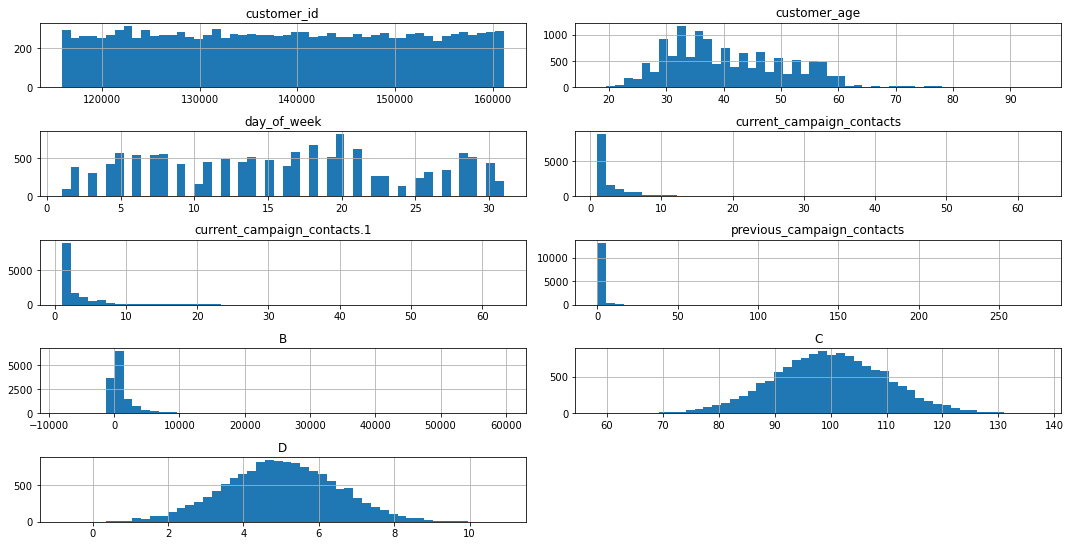

In [62]:
# histograms
df.hist(layout=(10,2),figsize=(15,15),bins = 50)
plt.tight_layout()

### Boxplots
The image presents box plots for various customer-related variables. Customer ID has a wide range with a median around 140,000. Customer age shows a broader spread, centered around 40. Day of week distribution is relatively even, while current and previous campaign contacts exhibit a wide range with medians around 40 and 100, respectively. Outliers in some plots suggest extreme values. Overall, the box plots provide a visual summary of data distribution and central tendency for each variable.

customer_id                       AxesSubplot(0.125,0.808774;0.352273x0.0712264)
customer_age                   AxesSubplot(0.547727,0.808774;0.352273x0.0712264)
day_of_week                       AxesSubplot(0.125,0.723302;0.352273x0.0712264)
current_campaign_contacts      AxesSubplot(0.547727,0.723302;0.352273x0.0712264)
current_campaign_contacts.1        AxesSubplot(0.125,0.63783;0.352273x0.0712264)
previous_campaign_contacts      AxesSubplot(0.547727,0.63783;0.352273x0.0712264)
B                                 AxesSubplot(0.125,0.552358;0.352273x0.0712264)
C                              AxesSubplot(0.547727,0.552358;0.352273x0.0712264)
D                                 AxesSubplot(0.125,0.466887;0.352273x0.0712264)
dtype: object

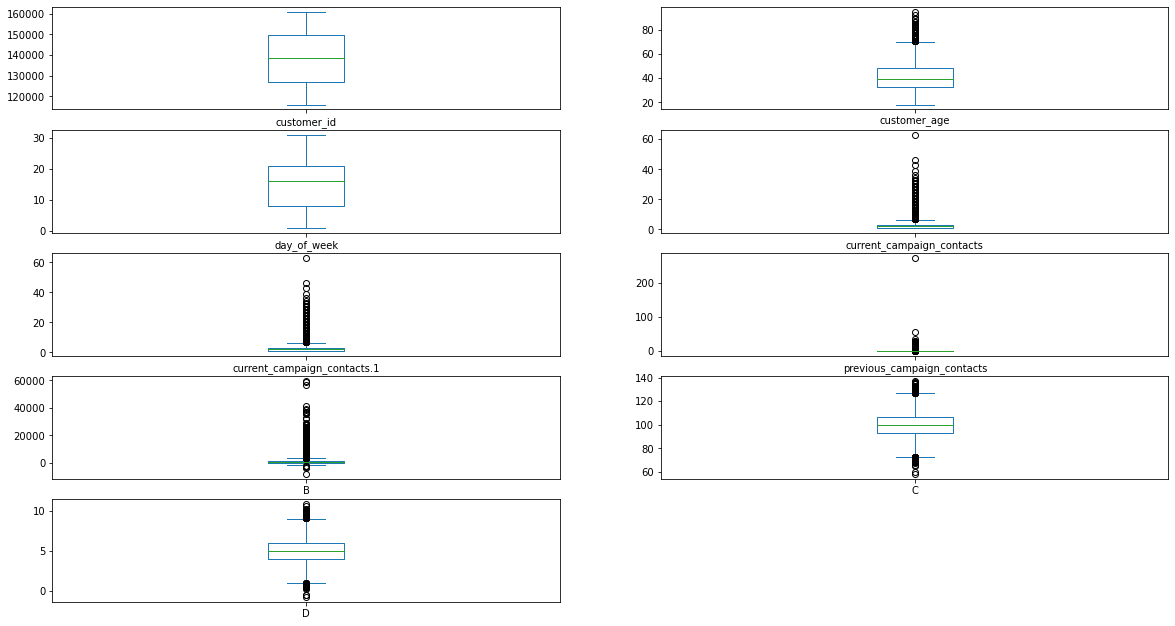

In [63]:
df.plot(kind='box', subplots=True, layout=(9,2), sharex=False, sharey=False, figsize = (20,20))

### Correlations
The following heatmap describes the correlations between each pair in the numeric columns. we can point to the fact that there seems to be a strong positive correlation between 'Current_Campaign_Contacts' and 'Current_Campaign_Contacts.1',which make sense since they They are approximately the same 
In addition, There seems to be a strong negative correlation between 'Customer_Age' and 'Current_Campaign_Contacts'. This could suggest that older customers are contacted less frequently.

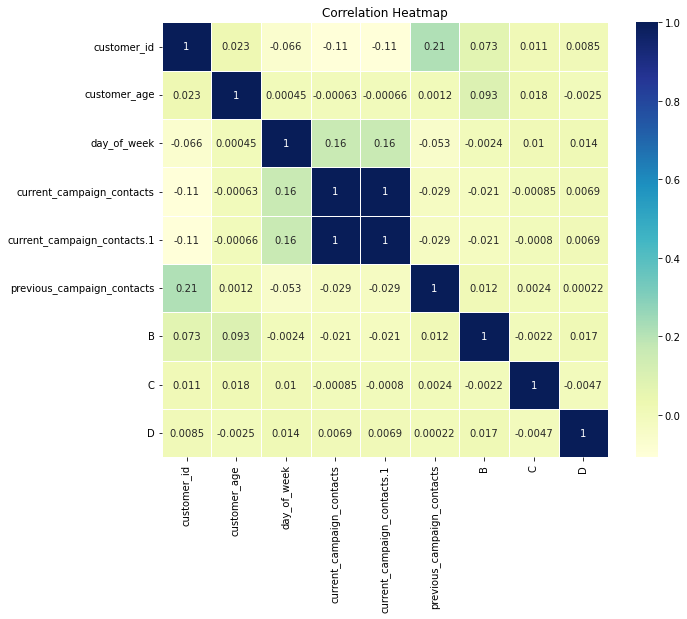

In [64]:

# Select only numeric columns from the DataFrame for correlation analysis
numeric_df = df.select_dtypes(include=['number'])

# Compute the correlation matrix for the numeric columns
correlation_matrix = numeric_df.corr()

# Create a heatmap to visualize the correlation matrix
plt.figure(figsize=(10, 8))  # Set the figure size to 10x8 inches

# Plot the heatmap with annotations and a color map for better visualization
sns.heatmap(correlation_matrix, 
            annot=True,  # Show correlation values on the heatmap
            cmap='YlGnBu',  # Use a yellow-green-blue color map
            xticklabels=correlation_matrix.columns,  # Label the x-axis with column names
            yticklabels=correlation_matrix.columns,  # Label the y-axis with column names
            linewidths=0.5)  # Add line widths between cells for better separation

# Set the title of the heatmap
plt.title('Correlation Heatmap')

# Display the heatmap
plt.show()


### Customer age distribution by "subscribed to new plan"
The graph illustrates the distribution of customer ages segmented by their subscription status to a new plan, with green bars indicating non-subscribers and pink bars indicating subscribers. Most customers are between 20 and 50 years old, peaking around 30-35. While non-subscribers dominate across all age groups, the proportion of subscribers is slightly higher in the 30-40 age range. There are few customers under 20 or over 60, and they exhibit lower subscription rates. This visualization highlights the age demographics and their correlation with the likelihood of subscribing to the new plan.

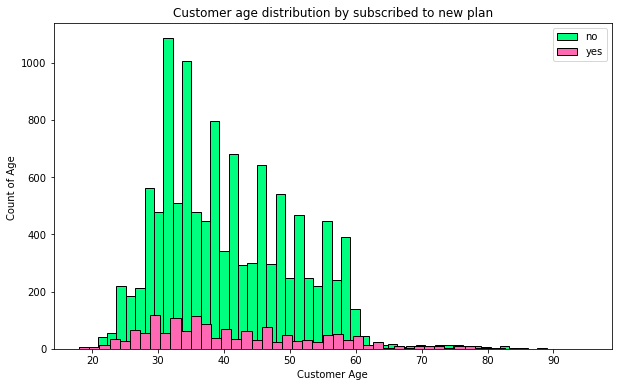

In [65]:
# Create a histogram to analyze the distribution of customer ages based on their subscription status

# Set the figure size to 10x6 inches for better readability
plt.figure(figsize=(10, 6))

# Filter the DataFrame to include only customers who did not subscribe to the new plan
df_no = df[df['subscribed_to_new_plan'] == 'no']

# Filter the DataFrame to include only customers who subscribed to the new plan
df_yes = df[df['subscribed_to_new_plan'] == 'yes']

# Plot histogram for customers who did not subscribe to the new plan
plt.hist(df_no['customer_age'], bins=50,  # Use 50 bins for the histogram
         label='no',  # Label for this histogram
         color='springgreen',  # Color of the histogram bars
         edgecolor='black')  # Color of the edges of the bars for better separation

# Plot histogram for customers who subscribed to the new plan
plt.hist(df_yes['customer_age'], bins=50,  # Use 50 bins for the histogram
         label='yes',  # Label for this histogram
         color='hotpink',  # Color of the histogram bars
         edgecolor='black')  # Color of the edges of the bars for better separation

# Label the x-axis as 'Customer Age'
plt.xlabel('Customer Age')

# Label the y-axis as 'Count of Age'
plt.ylabel('Count of Age ')

# Set the title of the histogram
plt.title('Customer age distribution by subscribed to new plan')

# Add a legend to differentiate between the two histograms
plt.legend()

# Display the histogram
plt.show()


# Job Type
### Job type distribution
The bar chart illustrates the distribution of job types within a dataset, with "management" as the most frequent category followed by "blue-collar" and "technician." The chart visually represents the count of individuals in each job type, revealing a varying frequency across different occupations. While "management" and "blue-collar" roles dominate, the inclusion of categories like "student" and "unknown" suggests a diverse population sample.

management       2848
blue-collar      2843
technician       2303
admin.           1526
services         1202
retired           669
self-employed     483
entrepreneur      422
unemployed        398
housemaid         380
student           281
Unknown            95
Name: job_type, dtype: int64


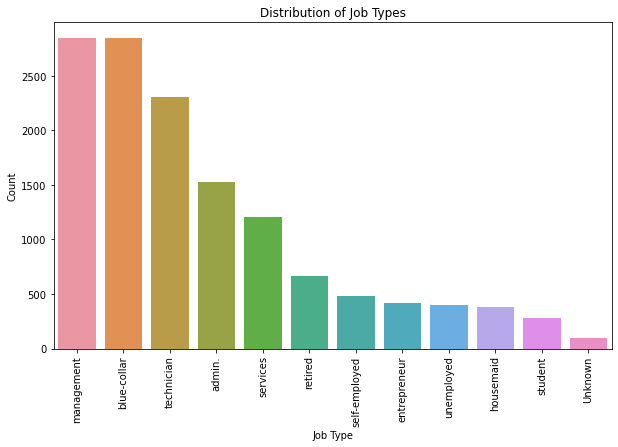

In [66]:
# Check if there are any null values in the 'job_type' column
if df['job_type'].isnull().any():
    # Fill null values in 'job_type' with 'Unknown' to handle missing data
    df['job_type'].fillna('Unknown', inplace=True)

# Calculate the distribution of job types and their counts
job_distribution = df['job_type'].value_counts()

# Print the job distribution
print(job_distribution)

# Set the figure size to 10x6 inches for better readability
plt.figure(figsize=(10, 6))

# Create a count plot to visualize the distribution of job types
sns.countplot(x='job_type',  # X-axis represents job types
              data=df,  # Data source is the DataFrame df
              order=job_distribution.index)  # Order the bars by job type counts

# Rotate x-axis labels by 90 degrees for better readability
plt.xticks(rotation=90)

# Set the title of the plot
plt.title('Distribution of Job Types')

# Label the x-axis as 'Job Type'
plt.xlabel('Job Type')

# Label the y-axis as 'Count'
plt.ylabel('Count')

# Display the plot
plt.show()

### Distribution of the label on job type
The table presents the count of customers across various job types segmented by their subscription status to a new plan, showing that non-subscribers consistently outnumber subscribers across all job types. Notably, the management and services job types have relatively higher counts of subscribers, suggesting job-related factors may influence the likelihood of subscribing to the new plan. Overall, this cross-tabulation highlights the varying subscription rates among different occupations.

In [67]:
cross_tab = pd.crosstab(df['job_type'], df['subscribed_to_new_plan'])
print(cross_tab) # calculating the percentage of subscribers to the new plan for each job type

subscribed_to_new_plan    no  yes
job_type                         
Unknown                   86    9
admin.                  1349  177
blue-collar             2639  204
entrepreneur             378   44
housemaid                348   32
management              2477  371
retired                  524  145
self-employed            424   59
services                1102  100
student                  202   79
technician              2049  254
unemployed               333   65


The image shows a heatmap visualizing the subscription rates to a new plan across different job types. The darker the blue, the higher the subscription rate. We can see that 'unknown' and 'blue-collar' job types have the highest subscription rates, while 'retired' and 'student' have lower rates. Overall, the heatmap provides a clear visual representation of the relationship between job type and subscription behavior.

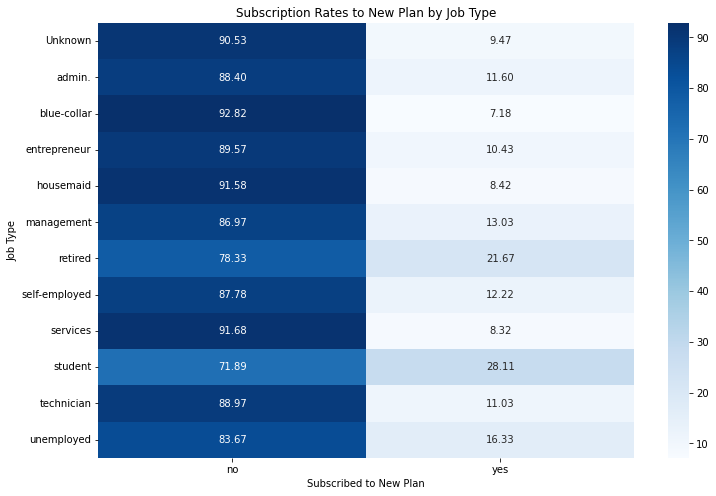

In [68]:
# Compute percentage values for the cross-tabulation table
cross_tab_percent = cross_tab.div(cross_tab.sum(1), axis=0) * 100

# Set the figure size to 12x8 inches for a larger and clearer view
plt.figure(figsize=(12, 8))

# Create a heatmap to visualize the percentage of subscription rates
# Annotate each cell with the percentage value, formatted to 2 decimal places
# Use a blue color map to represent the values
sns.heatmap(cross_tab_percent, 
            annot=True,  # Show percentage values on the heatmap
            fmt='.2f',  # Format numbers to 2 decimal places
            cmap='Blues')  # Use the 'Blues' color map

# Set the title of the heatmap
plt.title('Subscription Rates to New Plan by Job Type')

# Label the x-axis as 'Subscribed to New Plan'
plt.xlabel('Subscribed to New Plan')

# Label the y-axis as 'Job Type'
plt.ylabel('Job Type')

# Display the heatmap
plt.show()

### Job Type and Age
The box plot provides a visual representation of the interplay between job type, customer age, and subscription status. Age distribution varies across different job categories, with trends apparent in age ranges for occupations like students and management. The color-coded representation of subscription status (yes/no) allows for an initial assessment of subscription patterns within specific job types and age groups. Outliers, depicted as individual data points beyond the whiskers, indicate exceptional cases that might warrant further investigation. This visualization serves as a preliminary tool for identifying potential correlations and trends, suggesting areas for more in-depth analysis.

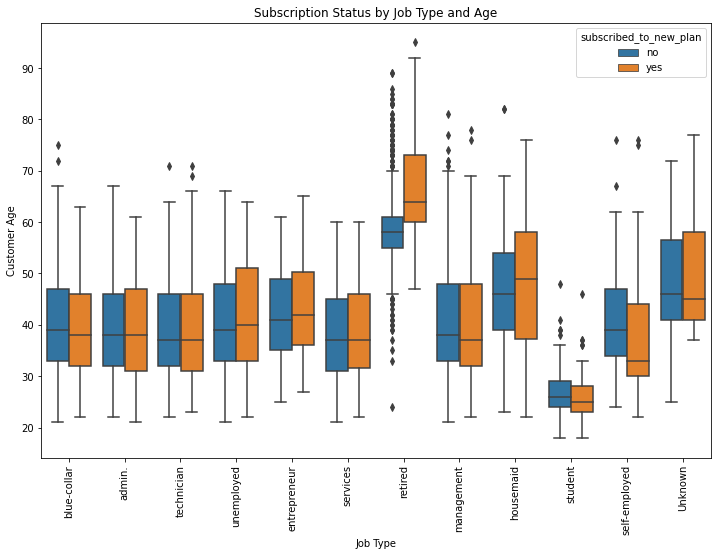

In [69]:
# Create a boxplot to examine the distribution of customer ages based on job type and subscription status

# Set the figure size to 12x8 inches for better visibility
plt.figure(figsize=(12, 8))

# Create a boxplot with 'job_type' on the x-axis and 'customer_age' on the y-axis
# Use hue to differentiate between customers who subscribed and those who did not
sns.boxplot(x='job_type',  # X-axis represents job types
            y='customer_age',  # Y-axis represents customer ages
            hue='subscribed_to_new_plan',  # Differentiate by subscription status
            data=df)  # Data source is the DataFrame df

# Rotate x-axis labels by 90 degrees for better readability
plt.xticks(rotation=90)

# Set the title of the boxplot
plt.title('Subscription Status by Job Type and Age')

# Label the x-axis as 'Job Type'
plt.xlabel('Job Type')

# Label the y-axis as 'Customer Age'
plt.ylabel('Customer Age')

# Display the boxplot
plt.show()

### Distribution of the label on job type
The image presents a bar chart comparing the subscription rates to a new plan across different job types. The x-axis lists various job types, while the y-axis represents the count of individuals within each job type. Two colored bars are displayed for each job type, differentiating between those who subscribed to the new plan ("yes") and those who did not ("no"). The chart reveals that "management" has the highest overall count, with a relatively larger proportion subscribing to the new plan compared to other job types like "unknown" and "blue-collar," which show lower subscription rates.

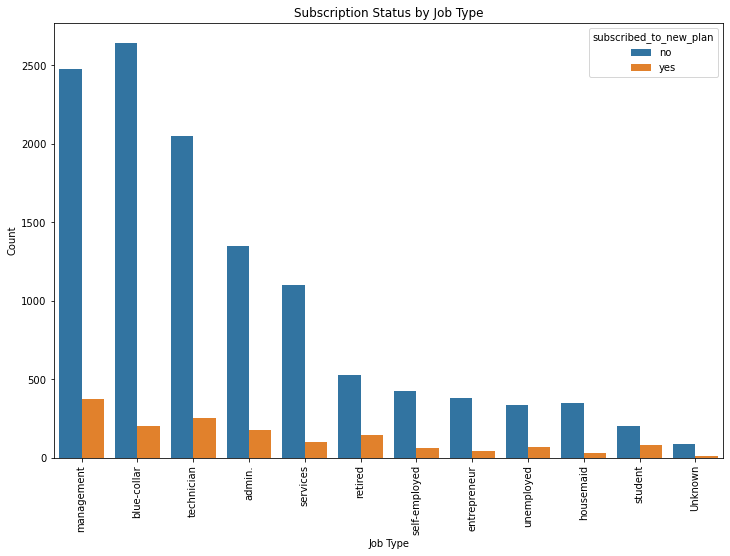

In [70]:
# Set the figure size to 12x8 inches for a larger and clearer view
plt.figure(figsize=(12, 8))

# Create a count plot to visualize the count of subscriptions by job type
# Use hue to differentiate between subscription statuses
# Order the job types by their frequency in descending order
sns.countplot(x='job_type',  # X-axis represents job types
              data=df,  # Data source is the DataFrame df
              hue='subscribed_to_new_plan',  # Differentiate by subscription status
              order=df['job_type'].value_counts().index)  # Order by frequency of job types

# Rotate x-axis labels by 90 degrees for better readability
plt.xticks(rotation=90)

# Set the title of the count plot
plt.title('Subscription Status by Job Type')

# Label the x-axis as 'Job Type'
plt.xlabel('Job Type')

# Label the y-axis as 'Count'
plt.ylabel('Count')

# Display the count plot
plt.show()

The output presents statistical summaries of customer age, current and previous campaign contacts grouped by job type, showing mean and standard deviation values for each metric.

In [71]:
# Calculate mean and standard deviation for 'customer_age', 'current_campaign_contacts', and 'previous_campaign_contacts'
# for each 'job_type'

# Group the DataFrame by 'job_type'
# Aggregate statistics by calculating the mean and standard deviation for the specified columns
job_stats = df.groupby('job_type').agg({
    'customer_age': ['mean', 'std'],  # Compute mean and standard deviation for customer age
    'current_campaign_contacts': ['mean', 'std'],  # Compute mean and standard deviation for current campaign contacts
    'previous_campaign_contacts': ['mean', 'std']  # Compute mean and standard deviation for previous campaign contacts
}).reset_index()  # Reset index to get 'job_type' as a column rather than an index

# Print the resulting DataFrame with aggregated statistics
print(job_stats)

         job_type customer_age            current_campaign_contacts            \
                          mean        std                      mean       std   
0         Unknown    47.684783  10.737558                  3.000000  2.949937   
1          admin.    39.441507   9.456356                  2.666448  3.131775   
2     blue-collar    40.332504   9.111080                  2.825888  3.213099   
3    entrepreneur    42.380723   8.836935                  2.601896  2.557239   
4       housemaid    46.018568  10.439398                  2.676316  2.282887   
5      management    40.561141   9.573217                  2.908357  3.452375   
6         retired    61.287009   9.366263                  2.415546  2.098074   
7   self-employed    40.134172   9.750826                  2.795031  2.897527   
8        services    38.430135   9.019178                  2.626978  2.943480   
9         student    26.434783   4.715863                  2.402135  2.592268   
10     technician    39.1617

### Distribution of the label on Job type and education level
The image presents a heatmap visualizing the distribution of education levels across different job types, with percentages represented by color intensity. The darker the blue, the higher the percentage of individuals with a specific education level within a job type. We can observe that "blue-collar" jobs have a high concentration of individuals with secondary education, while "management" and "entrepreneur" roles tend to have a higher proportion of individuals with tertiary education. Overall, the heatmap offers insights into the educational backgrounds prevalent in different job categories.

education_level    primary  secondary   tertiary
job_type                                        
Unknown          37.037037  35.185185  27.777778
admin.            4.021813  83.776414  12.201772
blue-collar      40.934372  57.508343   1.557286
entrepreneur     12.935323  39.800995  47.263682
housemaid        50.543478  32.880435  16.576087
management        3.721098  11.452312  84.826590
retired          34.115806  45.696401  20.187793
self-employed     6.623932  40.384615  52.991453
services          7.969152  87.403599   4.627249
student           6.086957  66.086957  27.826087
technician        2.657658  70.585586  26.756757
unemployed       17.783505  58.247423  23.969072


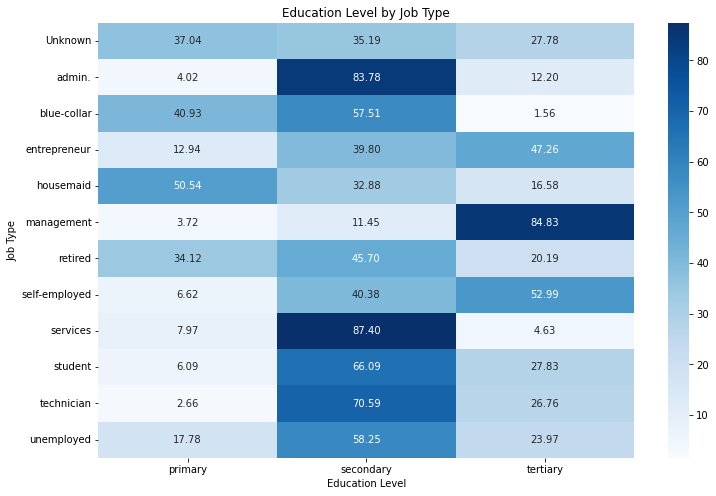

In [72]:
# Create a cross-tabulation of job type and education level, showing the percentage of subscription for each combination
cross_tab_education = pd.crosstab(df['job_type'], df['education_level'], normalize='index') * 100
print(cross_tab_education)  # Print the cross-tabulation table

# Set up the figure for the heatmap
plt.figure(figsize=(12, 8))

# Create a heatmap to visualize the cross-tabulation data
sns.heatmap(cross_tab_education, annot=True, fmt='.2f', cmap='Blues')

# Add title and axis labels
plt.title('Education Level by Job Type')
plt.xlabel('Education Level')
plt.ylabel('Job Type')

# Display the heatmap
plt.show()

### Distribution of 'preferred contact_method', 'Month', 'preferred call time'
#### Chart 1
The bar chart shows how people prefer to be contacted, with "call" being the most popular choice, followed by "unknown" and "email." A smaller number of people prefer "SMS." The chart highlights the distribution of preferred contact methods among the individuals in the dataset, indicating a clear preference for phone calls.

#### Chart 2
The bar chart illustrates the frequency of occurrences for each month within a dataset. The x-axis categorizes the twelve months of the year, while the y-axis represents the count of instances associated with each month. The chart indicates that May is the most prevalent month in the data, followed closely by April and July. In contrast, December exhibits the lowest frequency. This visual representation provides insights into the distribution of data points across different months.

#### Chart 3
we found Duplicate values: "Night" appears twice, indicating potential data entry errors.
Similar values: "eve" and "evening" seem to represent the same time period, requiring standardization.
Case sensitivity: "morning" and "Morning" likely refer to the same time period, necessitating consistent capitalization.
These inconsistencies can lead to inaccurate analysis and interpretation of the data. It's essential to standardize these values for reliable results.

Chart 1
Distribution for preferred_contact_method:
call       8681
Unknown    3930
email       426
SMS         413
Name: preferred_contact_method, dtype: int64



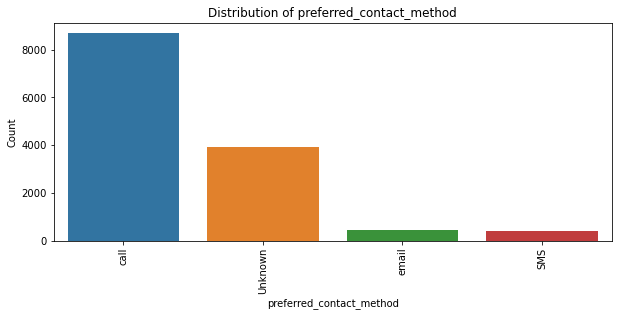

Chart 2
Distribution for Month:
may        4032
jul        2009
aug        1875
jun        1581
nov        1170
apr         851
feb         755
jan         399
oct         225
Unknown     175
sep         160
mar         146
dec          72
Name: Month, dtype: int64



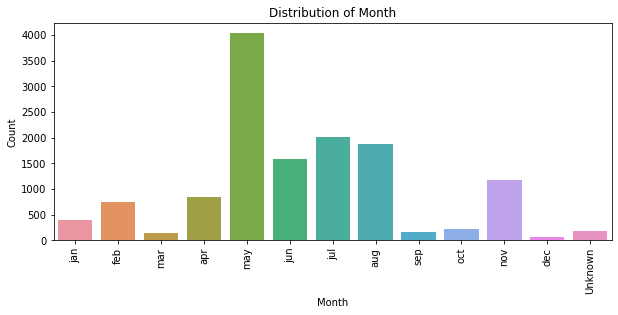

Chart 3
Distribution for preferred_call_time:
Night        1945
eve          1942
Morning      1932
Afternoon    1927
Evening      1922
morning      1907
Night        1873
Unknown         2
Name: preferred_call_time, dtype: int64



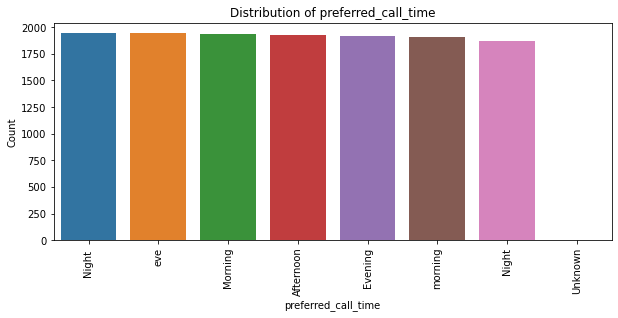

In [73]:
# Ensure that the specified columns are of object (categorical) type
columns_to_analyze = ['preferred_contact_method', 'Month', 'preferred_call_time']
df[columns_to_analyze] = df[columns_to_analyze].astype('object')

# Replace NaN values with 'Unknown' for the specified categorical columns
for column in columns_to_analyze:
    df[column].fillna('Unknown', inplace=True)

# Iterate through each column in columns_to_analyze to plot its distribution
i = 1
for column in columns_to_analyze:
    # Compute the distribution of values for the current column
    distribution = df[column].value_counts()
    print("Chart", i)  # Print chart number for reference
    print(f"Distribution for {column}:\n{distribution}\n")  # Print the distribution of values

    # Define the order of categories for plotting
    if column == "Month":
        # Define a specific order for months including 'Unknown'
        order = np.array(["jan", "feb", "mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec", "Unknown"])
    else:
        # Use the order based on the frequency of values
        order = distribution.index

    # Create a figure for the distribution plot
    plt.figure(figsize=(10, 4))  # Set the figure size to 10x4 inches

    # Create a count plot to visualize the distribution of values
    sns.countplot(x=df[column], order=order)  # Order categories for consistent visualization

    # Rotate x-axis labels by 90 degrees for better readability
    plt.xticks(rotation=90)

    # Set the title and labels for the plot
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Count')


    # Display the plot
    plt.show()

    # Increment the chart number
    i += 1

### Distribution of the label on day of month
The output presents a bar chart visualizing the distribution of orders across different days of the month. The x-axis lists the days of the month, while the y-axis represents the count of 'yes'. The chart shows that the number of orders peaks on certain days, like 1,10, and 24 is lower on other days, suggesting a pattern in order frequency throughout the month.

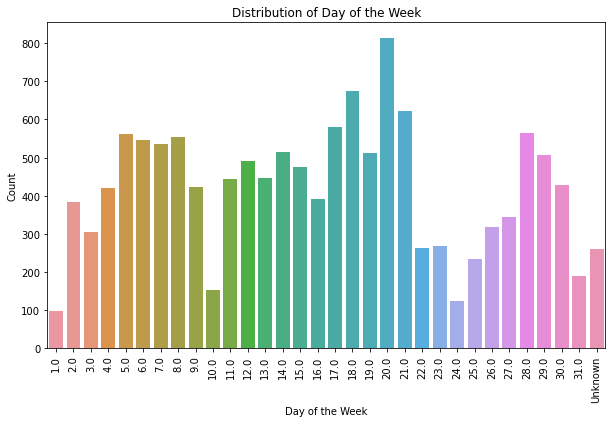

In [74]:
# Replace missing values in the 'day_of_week' column with 'Unknown'
df['day_of_week'].fillna('Unknown', inplace=True)

# Define the order of days of the week, placing 'Unknown' last
day_order = sorted(df['day_of_week'].unique(), key=lambda x: (x == 'Unknown', x))

# Set up the figure for the count plot
plt.figure(figsize=(10, 6))

# Create a count plot to visualize the distribution of 'day_of_week'
sns.countplot(x='day_of_week', data=df, order=day_order)

# Rotate x-axis labels for better readability
plt.xticks(rotation=90)

# Add title and axis labels
plt.title('Distribution of Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Count')

# Display the count plot
plt.show()

### Distribution of subscriptions on Day of Month
The chart compares the number of users who subscribed to a new plan ('yes') versus those who did not ('no') by day of the month. The x-axis represents days 1 to 31, plus an 'Unknown' category, while the y-axis shows the user count up to 800. Blue bars (non-subscribers) are consistently higher than orange bars (subscribers), peaking around the 20th day with non-subscribers near 800. Subscriptions remain low and stable throughout the month. The 'Unknown' category also shows more non-subscribers than subscribers. Overall, most users did not subscribe to the new plan on any day, with a significant spike in non-subscriptions mid-month.

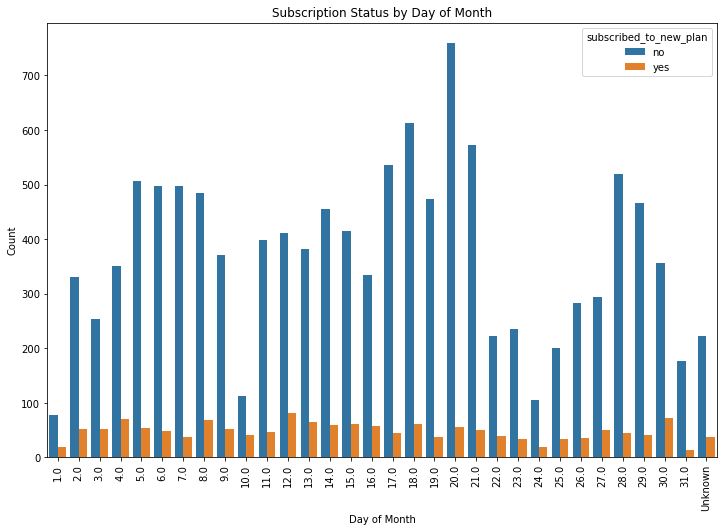

In [75]:
# Get unique values from the 'day_of_week' column
days = df['day_of_week'].unique()

# Filter out 'Unknown' values from the days array
days = days[days != "Unknown"]

# Define the order, ensuring 'Unknown' is placed at the end
# The lambda function sorts 'Unknown' to the end and keeps the original order for other days
ordered_days = sorted(df['day_of_week'].unique(), key=lambda x: (x == 'Unknown', x))

# Set the figure size to 12x8 inches for better readability
plt.figure(figsize=(12, 8))

# Create a count plot to visualize the distribution of 'day_of_week' with subscription status
# Use hue to differentiate between subscription statuses
# Order the x-axis categories according to 'ordered_days'
sns.countplot(x='day_of_week',  # X-axis represents days of the week
              hue='subscribed_to_new_plan',  # Differentiate by subscription status
              data=df,  # Data source is the DataFrame df
              order=ordered_days)  # Order days of the week, with 'Unknown' at the end

# Rotate x-axis labels by 90 degrees for better readability
plt.xticks(rotation=90)

# Set the title of the count plot
plt.title('Subscription Status by Day of Month')

# Label the x-axis as 'Day of Month'
plt.xlabel('Day of Month')

# Label the y-axis as 'Count'
plt.ylabel('Count')

# Display the count plot
plt.show()

### Distribution of subscriptions on Month
The chart shows monthly subscription trends, with May exhibiting the highest subscription rate and February and December demonstrating the lowest. Overall, subscription activity is higher during spring and summer months compared to autumn and winter. However, the presence of an "Unknown" category indicates missing data, potentially affecting the accuracy of the analysis.

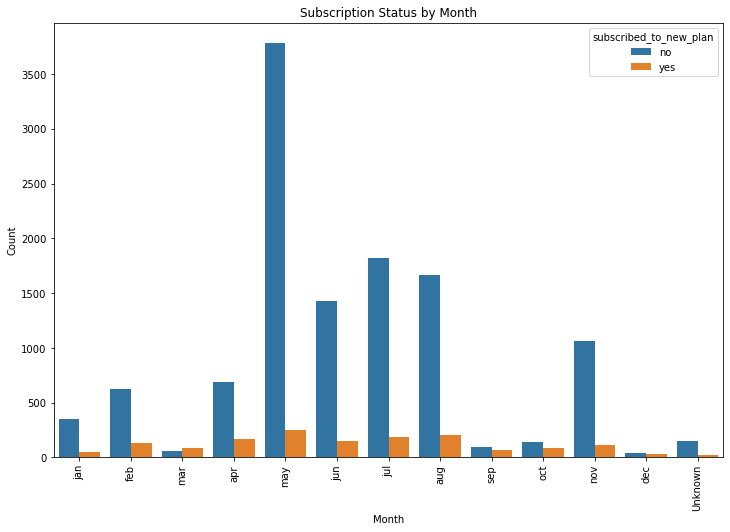

In [76]:
# Define the order of months, including 'Unknown' for any missing month data
ordered_month = np.array(["jan", "feb", "mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec", "Unknown"])

# Set up the figure for the count plot
plt.figure(figsize=(12, 8))

# Create a count plot to visualize subscription status by month
sns.countplot(x='Month', hue='subscribed_to_new_plan', data=df, order=ordered_month)

# Rotate x-axis labels for better readability
plt.xticks(rotation=90)

# Add title and axis labels
plt.title('Subscription Status by Month')
plt.xlabel('Month')
plt.ylabel('Count')

# Display the count plot
plt.show()

In [77]:
# columns for exploration
df_columns = ["marital_status", "education_level", "has_internet_service", "has_device_payment_plan","subscribed_to_new_plan"]

### Distribution of Marital Status
The bar chart shows that most people are married, with fewer individuals being single, divorced, or widowed. This indicates a potentially older demographic within the dataset. Further analysis could explore how marital status relates to other factors like age, income, or consumer behavior.

married     8069
single      3641
divorced    1543
Name: marital_status, dtype: int64


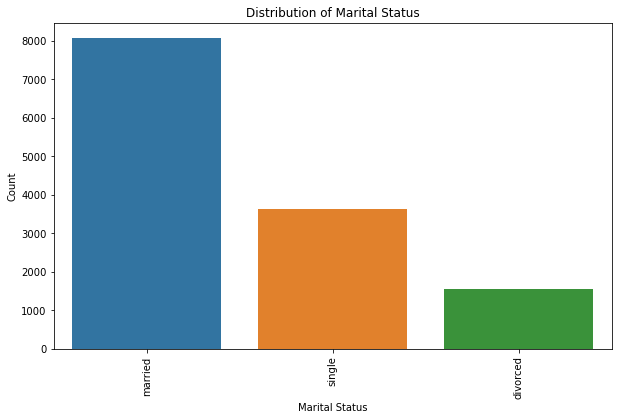

In [78]:
# Get the value counts (number of occurrences) for each marital status
marital_status_distribution = df['marital_status'].value_counts()

# Print the value counts
print(marital_status_distribution)

# Create a figure with a specific size (width=10, height=6)
plt.figure(figsize=(10, 6))

# Create a count plot using seaborn, specifying the data and variable to plot
# The 'order' parameter ensures bars are displayed in the same order as value_counts
sns.countplot(x='marital_status', data=df, order=marital_status_distribution.index)

# Rotate x-axis labels for better readability (optional)
plt.xticks(rotation=90)

# Add a title to the plot for clarity
plt.title('Distribution of Marital Status')

# Label the x-axis for understanding
plt.xlabel('Marital Status')

# Label the y-axis for understanding
plt.ylabel('Count')

# Display the plot
plt.show()

### Distribution of Education Level
The bar chart illustrates the distribution of education levels, with "Secondary" being the most common. A decreasing trend is observed from "Secondary" to "Primary," suggesting potential imbalances in educational attainment. Further analysis is needed to understand the factors influencing these disparities and to explore how education level correlates with other demographic variables.

secondary    6843
tertiary     4017
primary      2008
Name: education_level, dtype: int64


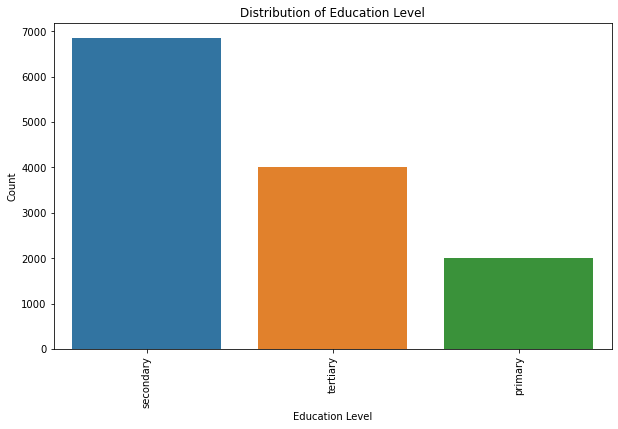

In [79]:
# Calculate the distribution of values in the 'education_level' column
education_level_distribution = df['education_level'].value_counts()

# Print the distribution of education levels
print(education_level_distribution)

# Set the figure size to 10x6 inches for better readability
plt.figure(figsize=(10, 6))

# Create a count plot to visualize the distribution of education levels
# Order the x-axis categories based on the frequency of education levels
sns.countplot(x='education_level',  # X-axis represents education levels
              data=df,  # Data source is the DataFrame df
              order=education_level_distribution.index)  # Order by frequency

# Rotate x-axis labels by 90 degrees for better readability
plt.xticks(rotation=90)

# Set the title of the count plot
plt.title('Distribution of Education Level')

# Label the x-axis as 'Education Level'
plt.xlabel('Education Level')

# Label the y-axis as 'Count'
plt.ylabel('Count')

# Display the count plot
plt.show()

### Distribution of the features: marital_status, education_level, has_internet_service, has_device_payment_plan.
Chart 1 and Chart 2: chart of heatmap and bar plot visualize the relationship between marital status and subscription status to a new plan. The heatmap shows the count of individuals in each marital status category who subscribed or did not subscribe, while the bar plot compares the subscription rates across different marital statuses.

Chart 3 and Chart 4: a heatmap and bar plot visualize the relationship between education level and subscription status to a new plan, with higher subscription rates observed for those with tertiary education.

Chart 5 and 6: a heatmap and bar plot visualize the relationship between having internet service and subscription status to a new plan, with higher subscription rates observed for those with internet service.

Chart 7 and 8: a heatmap and bar plot visualize the relationship between having a device payment plan and subscribing to a new plan using a heatmap and a grouped bar plot, showing a higher subscription rate for those with a device payment plan.

Chart 1


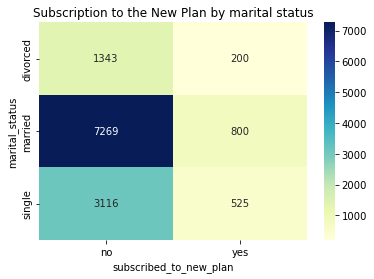

Chart 2


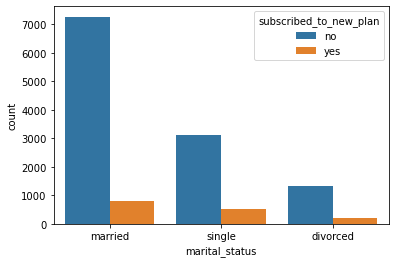

Chart 3


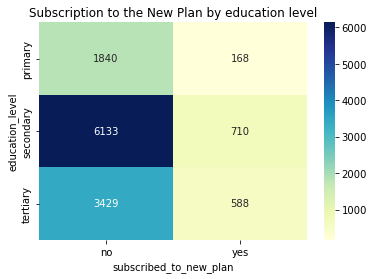

Chart 4


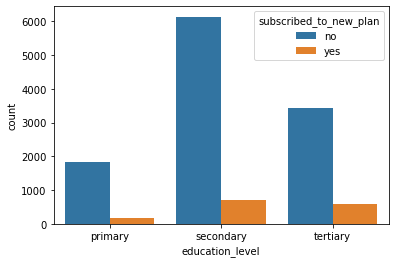

Chart 5


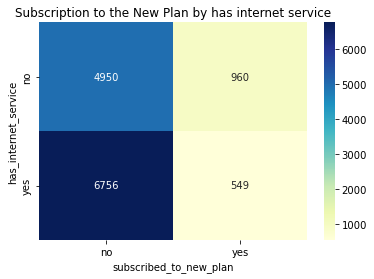

Chart 6


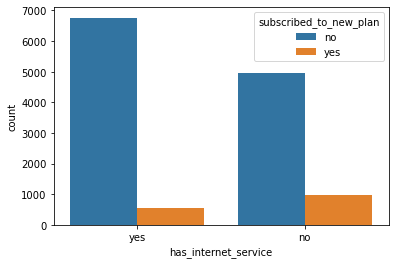

Chart 7


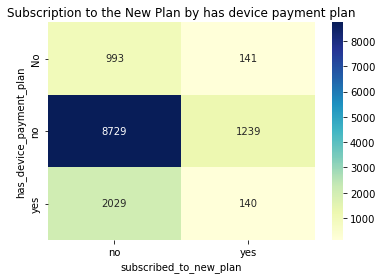

Chart 8


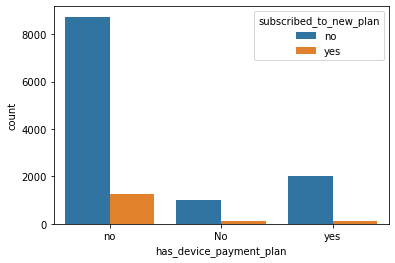

In [80]:
# Initialize a counter for chart numbering
i = 1

# Iterate over all columns except the last one
for col in df_columns[:-1]:
    # Print the current chart number
    print(f"Chart {i}")
    i += 1
    
    # Create a cross-tabulation (contingency table) of the current column and 'subscribed_to_new_plan'
    contingency_table = pd.crosstab(df[col], df["subscribed_to_new_plan"])
    
    # Plot a heatmap for the contingency table
    col_name = col.replace("_", " ")  # Replace underscores with spaces for better readability
    plt.title(f'Subscription to the New Plan by {col_name}')
    sns.heatmap(contingency_table, annot=True, fmt='d', cmap='YlGnBu')
    plt.show()
    
    # Print the next chart number
    print(f"Chart {i}")
    
    # Plot a grouped bar plot to visualize the counts of 'subscribed_to_new_plan' by the current column
    sns.countplot(x=df[col], hue=df["subscribed_to_new_plan"], data=df)
    plt.show()
    
    # Increment the chart number
    i += 1

# Outliers
From the boxplots graph you can see that there are many exceptions and we would like to handle them in order to analyze the data more accurately.
Outliers can significantly affect the values of statistics such as the mean and standard deviation. If we handle the outliers first, the normalization process will be more accurate and better reflect the distribution of the data.
If we don't handle the outliers before normalizing, the outliers may "pull" the normalized range and cause data distortion.

we handle outliers in the numeric columns in the train set. We start by defining a default IQR threshold and a custom threshold for column 'B'. For 'previous_campaign_contacts' we calculated according to data deviation method, we first calculated according to data Interquartile Range method, but more than 2000 unusual values were discovered and this is a large number that can cause data distortion, therefore we used data deviation method. For other numeric columns, we compute the IQR and filter out outliers using the specified thresholds. This process cleans the data by replacing the outliers with upper and lower limit.

In [81]:
# # Compute Z-scores
# z_scores = np.abs(stats.zscore(df["B"]))

# # Define the threshold for outliers
# threshold = 7

# # Filter out rows where Z-score is above the threshold
# df_filtered = df[z_scores < threshold]

# df_filtered["B"].count()

### Outliers(df)
The code defines a function to detect and handle outliers in a DataFrame, using either a default or custom IQR threshold. It applies this function to a dataset containing customer information, including age, job type, marital status, and other variables, and then displays the modified DataFrame with potential outliers addressed

In [82]:
def Outliers(df):
    # Selecting only numeric columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns

    # Defining default IQR threshold for outlier detection
    default_threshold = 1.5

    # Defining custom IQR threshold for specific columns
    custom_thresholds = {
        'B': 6.5  # Custom threshold for column 'B'
    }

    # Iterating over each numeric column to detect and replace outliers
    for col in numeric_cols:
        if col == 'previous_campaign_contacts':
            # For 'previous_campaign_contacts', using mean and standard deviation method
            avg_previous_campaign_contacts = df['previous_campaign_contacts'].mean()
            std_previous_campaign_contacts = df['previous_campaign_contacts'].std()

            # Defining upper and lower limits as mean ± 3*std
            upper_limit = avg_previous_campaign_contacts + 3 * std_previous_campaign_contacts
            lower_limit = avg_previous_campaign_contacts - 3 * std_previous_campaign_contacts
        else:
            # For other columns, using IQR method
            threshold = custom_thresholds.get(col, default_threshold)  # Get custom threshold if exists, else default

            Q1 = df[col].quantile(0.25)  # First quartile (25th percentile)
            Q3 = df[col].quantile(0.75)  # Third quartile (75th percentile)
            IQR = Q3 - Q1  # Interquartile range

            # Defining upper and lower limits as Q1 - threshold * IQR and Q3 + threshold * IQR
            upper_limit = Q3 + threshold * IQR
            lower_limit = Q1 - threshold * IQR
        
        # Replacing outliers with the respective limits
        df[col] = df[col].apply(lambda x: lower_limit if x < lower_limit else (upper_limit if x > upper_limit else x))

    return df

# Apply the outlier detection and replacement function to the DataFrame
df = Outliers(df)
df

,customer_id,customer_age,job_type,marital_status,education_level,has_internet_service,has_device_payment_plan,preferred_contact_method,day_of_week,Month,preferred_call_time,current_campaign_contacts,current_campaign_contacts.1,previous_campaign_contacts,previous_campaign_outcome,A,B,C,D,subscribed_to_new_plan
0,119502.0,42.0,blue-collar,married,primary,yes,no,Unknown,15.0,may,Evening,4.0,4.0,0.0,NaN,no,2519.0,82.213907,2.669578,no
1,148910.0,32.0,admin.,married,secondary,yes,no,call,17.0,apr,Evening,4.0,4.0,0.0,NaN,NaN,923.0,87.685605,5.624491,no
2,160215.0,53.0,blue-collar,married,primary,no,no,call,28.0,jul,Night,3.0,3.0,1.0,success,no,306.0,90.640048,1.264906,yes
3,124011.0,32.0,technician,single,tertiary,yes,no,Unknown,2.0,jun,Night,5.0,5.0,0.0,NaN,no,257.0,97.262825,3.387077,no
4,154850.0,28.0,admin.,single,secondary,yes,no,call,Unknown,may,morning,1.0,1.0,0.0,NaN,no,-36.0,100.326495,7.154399,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13445,139958.0,35.0,management,married,tertiary,yes,no,Unknown,21.0,oct,morning,1.0,1.0,0.0,NaN,no,0.0,100.675838,3.904939,no
13446,154003.0,33.0,technician,single,tertiary,yes,yes,email,15.0,may,Night,4.0,4.0,3.0,other,no,109.0,92.078893,2.262702,no
13447,121476.0,39.0,self-employed,married,secondary,yes,no,Unknown,23.0,may,Evening,4.0,4.0,0.0,NaN,no,31.0,102.652590,4.336585,no
13448,123524.0,37.0,management,divorced,secondary,yes,no,Unknown,30.0,may,Night,1.0,1.0,0.0,NaN,no,16.0,89.263352,5.677371,yes


# Missing Values

We assessed the percentage of missing values for each column and created a DataFrame to display and sort these percentages. If the column contains less than 50% values, it will not be reliable, so we will want to handle it. We discovered that the "previous_campaign_outcome" column had 81.4% missing data, so we handled it. Additionally, we noted that current_campaign_contacts.1 had a higher percentage of missing values compared to current_campaign_contacts, and since they were perfectly correlated, we chose to keep current_campaign_contacts for its lower missing data percentage.
We wanted to identify rows with more than 5 missing values and display their indices, to ensure that the train set includes rows with fewer missing values. but we didn't find any.


In [83]:
# Calculate the percentage of missing values in each column in the given dataset
percent_missing = df.isnull().sum() * 100 / len(df) 

# Create a DataFrame to store the column names and their corresponding percentage of missing values
missing_value_df = pd.DataFrame({'column_name': df.columns,
                                 'percent_missing': percent_missing})

# Sort the DataFrame by the percentage of missing values in ascending order
missing_value_df.sort_values('percent_missing', inplace=True)

# Display the sorted DataFrame
missing_value_df

# It can be seen that 'previous_campaign_outcome' has 81.4% missing data and can be removed

# It can also be seen that 'current_campaign_contacts.1' has more missing data than 'current_campaign_contacts'.
# Since they have a correlation of 1, we prefer to remove the one with the highest percentage of missing data.

,column_name,percent_missing
Month,Month,0.000000
preferred_call_time,preferred_call_time,0.000000
day_of_week,day_of_week,0.000000
preferred_contact_method,preferred_contact_method,0.000000
subscribed_to_new_plan,subscribed_to_new_plan,0.000000
job_type,job_type,0.000000
current_campaign_contacts,current_campaign_contacts,0.007435
previous_campaign_contacts,previous_campaign_contacts,0.029740
current_campaign_contacts.1,current_campaign_contacts.1,0.037175
customer_id,customer_id,0.059480


The output shows the percentage of missing values in each column of a DataFrame, sorted in ascending order. The columns with the highest percentage of missing values are 'previous_campaign_outcome' (81.44%), 'education_level' (4.33%), and 'has_internet_service' (1.74%), while most columns have very few or no missing values. Missing values will be filled in the further stages of the project

#### previous_campaign_outcome
We initially planned to remove 'previous_campaign_outcome', but decided to keep it and fill in the missing values with the word "other" instead.

In [84]:
# According to the table above and correlation analysis:
# The 'current_campaign_contacts.1' column will be removed because it is a duplicate of another column
df = df.drop(columns=['current_campaign_contacts.1'], axis=1)

# Instead of removing the 'previous_campaign_outcome' column, the missing values are being filled with the string "other".
df['previous_campaign_outcome'] = df['previous_campaign_outcome'].fillna("other")

# Display the updated DataFrame.
df

,customer_id,customer_age,job_type,marital_status,education_level,has_internet_service,has_device_payment_plan,preferred_contact_method,day_of_week,Month,preferred_call_time,current_campaign_contacts,previous_campaign_contacts,previous_campaign_outcome,A,B,C,D,subscribed_to_new_plan
0,119502.0,42.0,blue-collar,married,primary,yes,no,Unknown,15.0,may,Evening,4.0,0.0,other,no,2519.0,82.213907,2.669578,no
1,148910.0,32.0,admin.,married,secondary,yes,no,call,17.0,apr,Evening,4.0,0.0,other,NaN,923.0,87.685605,5.624491,no
2,160215.0,53.0,blue-collar,married,primary,no,no,call,28.0,jul,Night,3.0,1.0,success,no,306.0,90.640048,1.264906,yes
3,124011.0,32.0,technician,single,tertiary,yes,no,Unknown,2.0,jun,Night,5.0,0.0,other,no,257.0,97.262825,3.387077,no
4,154850.0,28.0,admin.,single,secondary,yes,no,call,Unknown,may,morning,1.0,0.0,other,no,-36.0,100.326495,7.154399,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13445,139958.0,35.0,management,married,tertiary,yes,no,Unknown,21.0,oct,morning,1.0,0.0,other,no,0.0,100.675838,3.904939,no
13446,154003.0,33.0,technician,single,tertiary,yes,yes,email,15.0,may,Night,4.0,3.0,other,no,109.0,92.078893,2.262702,no
13447,121476.0,39.0,self-employed,married,secondary,yes,no,Unknown,23.0,may,Evening,4.0,0.0,other,no,31.0,102.652590,4.336585,no
13448,123524.0,37.0,management,divorced,secondary,yes,no,Unknown,30.0,may,Night,1.0,0.0,other,no,16.0,89.263352,5.677371,yes


In [85]:
# Identify rows with more than 5 missing values
empty_rows = df.isna().sum(axis=1) > 5

# Display the index of rows considered empty
empty_row_indices = df[empty_rows].index
print("Indices of empty rows:", empty_row_indices.tolist())

# Remove the identified empty rows from the DataFrame
df_cleaned = df[~empty_rows]
print("\nDataFrame after removing empty rows:\n", df_cleaned)

Indices of empty rows: []

DataFrame after removing empty rows:
        customer_id  customer_age       job_type marital_status  \
0         119502.0          42.0    blue-collar        married   
1         148910.0          32.0         admin.        married   
2         160215.0          53.0    blue-collar        married   
3         124011.0          32.0     technician         single   
4         154850.0          28.0         admin.         single   
...            ...           ...            ...            ...   
13445     139958.0          35.0     management        married   
13446     154003.0          33.0     technician         single   
13447     121476.0          39.0  self-employed        married   
13448     123524.0          37.0     management       divorced   
13449     133475.0          50.0     management        married   

      education_level has_internet_service has_device_payment_plan  \
0             primary                  yes                      no   
1 

# Mapping wrong categorical values

The following code performs a mapping that unites categories that have the same meaning but are written with changes such as a capital letter versus a small letter or there are deficiencies in the words that cause this to create additional categories that are not needed. The mapping is done on the words: {'No': 'no', 'morning': 'Morning','eve': 'Evening','Night ': 'Night'} and is used in the columns: 'has_device_payment_plan' and 'preferred_call_time' '

In [86]:
def mapping_wrong_values(df):
    # Define a dictionary to map incorrect values to the correct ones
    mapping = {'No': 'no', 'morning': 'Morning', 'eve': 'Evening', 'Night ': 'Night'}
    
    # Replace incorrect values in the 'has_device_payment_plan' column with the correct ones
    df['has_device_payment_plan'] = df['has_device_payment_plan'].replace(mapping)
    
    # Replace incorrect values in the 'preferred_call_time' column with the correct ones
    df['preferred_call_time'] = df['preferred_call_time'].replace(mapping)
    
    # Verify that we get only the correct values for 'preferred_call_time'
    df['preferred_call_time'].unique()
    
    # Verify that we get only the correct values for 'has_device_payment_plan'
    df['has_device_payment_plan'].unique()
    
    return df

# Apply the function to the DataFrame
df = mapping_wrong_values(df)

# Display the updated DataFrame
df

,customer_id,customer_age,job_type,marital_status,education_level,has_internet_service,has_device_payment_plan,preferred_contact_method,day_of_week,Month,preferred_call_time,current_campaign_contacts,previous_campaign_contacts,previous_campaign_outcome,A,B,C,D,subscribed_to_new_plan
0,119502.0,42.0,blue-collar,married,primary,yes,no,Unknown,15.0,may,Evening,4.0,0.0,other,no,2519.0,82.213907,2.669578,no
1,148910.0,32.0,admin.,married,secondary,yes,no,call,17.0,apr,Evening,4.0,0.0,other,NaN,923.0,87.685605,5.624491,no
2,160215.0,53.0,blue-collar,married,primary,no,no,call,28.0,jul,Night,3.0,1.0,success,no,306.0,90.640048,1.264906,yes
3,124011.0,32.0,technician,single,tertiary,yes,no,Unknown,2.0,jun,Night,5.0,0.0,other,no,257.0,97.262825,3.387077,no
4,154850.0,28.0,admin.,single,secondary,yes,no,call,Unknown,may,Morning,1.0,0.0,other,no,-36.0,100.326495,7.154399,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13445,139958.0,35.0,management,married,tertiary,yes,no,Unknown,21.0,oct,Morning,1.0,0.0,other,no,0.0,100.675838,3.904939,no
13446,154003.0,33.0,technician,single,tertiary,yes,yes,email,15.0,may,Night,4.0,3.0,other,no,109.0,92.078893,2.262702,no
13447,121476.0,39.0,self-employed,married,secondary,yes,no,Unknown,23.0,may,Evening,4.0,0.0,other,no,31.0,102.652590,4.336585,no
13448,123524.0,37.0,management,divorced,secondary,yes,no,Unknown,30.0,may,Night,1.0,0.0,other,no,16.0,89.263352,5.677371,yes


### Distribution of the target on preferred contact method
The bar chart illustrates the relationship between preferred contact method and subscription status for a new plan. The height of each bar represents the count of individuals within each contact method category, with different colors distinguishing between those who subscribed and those who did not. The chart reveals that "call" contact method has the highest overall count, with a relatively larger proportion that not subscribing to the new plan compared to other methods like "Unknow" , "email" and "SMS," which show lower subscription rates.

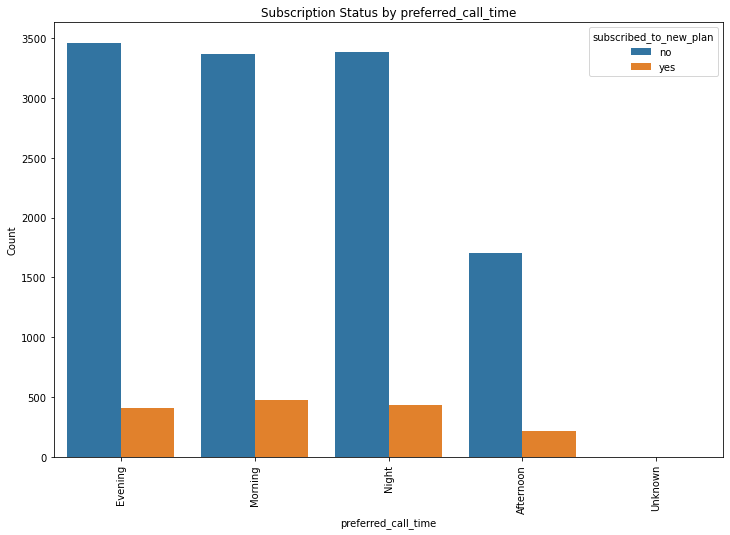

In [87]:
### Now we can see the actual distribution of the feature preferred call time
# Set the size of the plot figure to 12x8 inches for better visualization
plt.figure(figsize=(12, 8))

# Create a count plot for the 'preferred_call_time' feature,
# with different hues representing the 'subscribed_to_new_plan' status
sns.countplot(
    x='preferred_call_time', 
    hue='subscribed_to_new_plan', 
    data=df, 
    order=df['preferred_call_time'].value_counts().index  # Order the categories by frequency
)

# Rotate the x-axis labels by 90 degrees for better readability
plt.xticks(rotation=90)

# Set the title of the plot to describe the content
plt.title('Subscription Status by preferred_call_time')

# Label the x-axis as 'preferred_call_time'
plt.xlabel('preferred_call_time')

# Label the y-axis as 'Count' to indicate the number of occurrences
plt.ylabel('Count')

# Display the plot
plt.show()

# Fill missing values


To address missing values in our dataset, we identified numeric columns and filled the missing values with the knn method for each column. And for the categorical columns we filled the missing values with "Unknown" except of the columns "day_of_week" and "education_level" that were fillied with the most frequent category.

## Numeric columns

### Knn_fill(df)
We chose this method because it is straightforward and prevents data loss, maintaining the overall distribution of the data while allowing for comprehensive analysis.

We started by replacing all the "Unknown" values in our dataset with missing values. This helps us identify and handle these values more effectively.

Next, we focused on the numerical columns. We converted these columns to floating-point numbers for better compatibility with the KNN imputation method. We then used KNN to fill in the missing values in these numerical columns. KNN looks at similar data points to estimate the missing value.

To ensure data consistency, we rounded certain columns to whole numbers. These columns included 'day_of_week', 'current_campaign_contacts', 'previous_campaign_contacts', and 'B'.

Finally, we checked if the 'day_of_week' column only contained whole numbers, as expected. This step verifies the data cleaning process.

In [88]:
# Replace 'Unknown' values with NaN
df.replace('Unknown', np.nan, inplace=True)

def Knn_fill(df):
    # Select numeric columns from the DataFrame
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    
    # Ensure numeric columns are of float type
    df[numeric_cols] = df[numeric_cols].astype(float)
    
    # Initialize the KNN imputer with the desired number of neighbors
    imputer = KNNImputer(n_neighbors=5)
    
    # Fit the imputer on the data and transform it
    df[numeric_cols] = imputer.fit_transform(df[numeric_cols])
    
    # List of columns to round to the nearest integer
    round_cols = ["day_of_week", "current_campaign_contacts", "previous_campaign_contacts", "B"]
    
    # Round the specified columns to 0 decimal places
    df[round_cols] = df[round_cols].apply(lambda x: x.round(0))
    
    return df

# Apply the KNN imputation and rounding to the DataFrame
df = Knn_fill(df)

# Check if 'day_of_week' column contains only integer values
print(df["day_of_week"].unique())

[15. 17. 28.  2. 14. 31. 12. 30.  8. 21. 29.  4.  7. 13.  6. 18.  9. 20.
 27. 23. 16. 24. 25. 19. 11. 26. 22.  1.  5.  3. 10.]


## Categorical columns

To handle categorical variables, we first filled any missing values with 'Unknown' to ensure no null values remain. we chose to fill missing values with "Unknow" because creating a new category can help distinguish between missing data and other sets, this can help the model understand that it is a separate category with unique behavior. We then identified the categorical columns and converted them into dummy variables using one-hot encoding. This approach involves creating binary columns for each category. By converting categorical variables into numerical format, we ensured compatibility with various machine learning algorithms and improved the dataset's usability for analysis.

## Label encoding

### label_coding(df)
First, we made a list of all the months and their matching numbers. Then, we did the same for different education levels. We looked at our data and replaced the month names with their corresponding numbers. We did the same for the education level.
After that, we removed the old columns with the text. To handle missing values, we found the most common number for each column and used it to fill in the empty spots. We chose this method because it is straightforward and easy to implement and it doesn't affect the distribution of both columns significantly.

In [89]:
def label_coding(df):
    # Define the mapping from month names to month numbers
    month_mapping = {
        'jan': 1,
        'feb': 2,
        'mar': 3,
        'apr': 4,
        'may': 5,
        'jun': 6,
        'jul': 7,
        'aug': 8,
        'sep': 9,
        'oct': 10,
        'nov': 11,
        'dec': 12
    }
    
    # Define the mapping from education levels to numerical codes
    education_level = {
        'primary': 1,
        'secondary': 2,
        'tertiary': 3
    }
    
    # Apply the mapping to transform month names into month numbers
    df['Month_Number'] = df['Month'].map(month_mapping)
    
    # Apply the mapping to transform education levels into numerical codes
    df['education_level_Number'] = df['education_level'].map(education_level)
    
    # Drop the original 'Month' and 'education_level' columns
    df = df.drop(columns=['Month', 'education_level'], axis=1)
    
    # Find the most frequent month number
    most_frequent_month = df['Month_Number'].mode()[0]
    
    # Find the most frequent education level number
    most_frequent_education_level = df['education_level_Number'].mode()[0]
    
    # Fill missing values in 'Month_Number' with the most frequent month number
    df['Month_Number'].fillna(most_frequent_month, inplace=True)
    
    # Fill missing values in 'education_level_Number' with the most frequent education level number
    df['education_level_Number'].fillna(most_frequent_education_level, inplace=True)
    
    return df

# Apply the function to the DataFrame
df = label_coding(df)

# Display the updated DataFrame
df

,customer_id,customer_age,job_type,marital_status,has_internet_service,has_device_payment_plan,preferred_contact_method,day_of_week,preferred_call_time,current_campaign_contacts,previous_campaign_contacts,previous_campaign_outcome,A,B,C,D,subscribed_to_new_plan,Month_Number,education_level_Number
0,119502.0,42.0,blue-collar,married,yes,no,NaN,15.0,Evening,4.0,0.0,other,no,2519.0,82.213907,2.669578,no,5.0,1.0
1,148910.0,32.0,admin.,married,yes,no,call,17.0,Evening,4.0,0.0,other,NaN,923.0,87.685605,5.624491,no,4.0,2.0
2,160215.0,53.0,blue-collar,married,no,no,call,28.0,Night,3.0,1.0,success,no,306.0,90.640048,1.264906,yes,7.0,1.0
3,124011.0,32.0,technician,single,yes,no,NaN,2.0,Night,5.0,0.0,other,no,257.0,97.262825,3.387077,no,6.0,3.0
4,154850.0,28.0,admin.,single,yes,no,call,14.0,Morning,1.0,0.0,other,no,-36.0,100.326495,7.154399,no,5.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13445,139958.0,35.0,management,married,yes,no,NaN,21.0,Morning,1.0,0.0,other,no,0.0,100.675838,3.904939,no,10.0,3.0
13446,154003.0,33.0,technician,single,yes,yes,email,15.0,Night,4.0,3.0,other,no,109.0,92.078893,2.262702,no,5.0,3.0
13447,121476.0,39.0,self-employed,married,yes,no,NaN,23.0,Evening,4.0,0.0,other,no,31.0,102.652590,4.336585,no,5.0,2.0
13448,123524.0,37.0,management,divorced,yes,no,NaN,30.0,Night,1.0,0.0,other,no,16.0,89.263352,5.677371,yes,5.0,2.0


In [90]:
df.dtypes # Display the data types of each column in df

customer_id                   float64
customer_age                  float64
job_type                       object
marital_status                 object
has_internet_service           object
has_device_payment_plan        object
preferred_contact_method       object
day_of_week                   float64
preferred_call_time            object
current_campaign_contacts     float64
previous_campaign_contacts    float64
previous_campaign_outcome      object
A                              object
B                             float64
C                             float64
D                             float64
subscribed_to_new_plan         object
Month_Number                  float64
education_level_Number        float64
dtype: object

### one_hot_encoding(df)
This function preps the train set by focusing on its categorical columns. It identifies these columns and fills in any missing values with 'Unknown'. Then, it applies one-hot encoding to turn the categorical data into numerical format, making sure to drop one category to avoid redundancy. The result is a cleaned-up DataFrame that's ready for further analysis.

In [91]:
def one_hot_encoding(df):
    # Identify categorical columns by selecting columns with 'object' or 'category' data types
    categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()
    # Adding the columns'Month_Number', 'education_level_Number' to the list
    categorical_columns += ['Month_Number', 'education_level_Number']

    # Convert identified categorical columns to string type to avoid issues with fillna method
    df[categorical_columns] = df[categorical_columns].astype(str)

    # Fill missing values in the DataFrame with 'Unknown' for object columns
    df.fillna('Unknown', inplace=True)

    # Apply one-hot encoding to the categorical columns, dropping the first category to avoid multicollinearity
    df = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

    # List of columns that are redundant and should be removed
    columns_to_drop = ['A_no', 'has_internet_service_no', 'has_device_payment_plan_no']
    # Drop the specified redundant columns if they exist in the DataFrame
    df = df.drop(columns=[col for col in columns_to_drop if col in df.columns], axis=1)

    # Rename columns for better readability and consistency
    df = df.rename(columns={
        "subscribed_to_new_plan_yes": "subscribed_to_new_plan",
        "A_yes": "A",
        "has_internet_service_yes": "has_internet_service",
        "has_device_payment_plan_yes": "has_device_payment_plan"
    })

    # Return the modified DataFrame
    return df

# Apply the one_hot_encoding function to the DataFrame 'df'
df = one_hot_encoding(df)

# Display the resulting DataFrame
df

,customer_id,customer_age,day_of_week,current_campaign_contacts,previous_campaign_contacts,B,C,D,job_type_blue-collar,job_type_entrepreneur,...,Month_Number_2.0,Month_Number_3.0,Month_Number_4.0,Month_Number_5.0,Month_Number_6.0,Month_Number_7.0,Month_Number_8.0,Month_Number_9.0,education_level_Number_2.0,education_level_Number_3.0
0,119502.0,42.0,15.0,4.0,0.0,2519.0,82.213907,2.669578,1,0,...,0,0,0,1,0,0,0,0,0,0
1,148910.0,32.0,17.0,4.0,0.0,923.0,87.685605,5.624491,0,0,...,0,0,1,0,0,0,0,0,1,0
2,160215.0,53.0,28.0,3.0,1.0,306.0,90.640048,1.264906,1,0,...,0,0,0,0,0,1,0,0,0,0
3,124011.0,32.0,2.0,5.0,0.0,257.0,97.262825,3.387077,0,0,...,0,0,0,0,1,0,0,0,0,1
4,154850.0,28.0,14.0,1.0,0.0,-36.0,100.326495,7.154399,0,0,...,0,0,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13445,139958.0,35.0,21.0,1.0,0.0,0.0,100.675838,3.904939,0,0,...,0,0,0,0,0,0,0,0,0,1
13446,154003.0,33.0,15.0,4.0,3.0,109.0,92.078893,2.262702,0,0,...,0,0,0,1,0,0,0,0,0,1
13447,121476.0,39.0,23.0,4.0,0.0,31.0,102.652590,4.336585,0,0,...,0,0,0,1,0,0,0,0,1,0
13448,123524.0,37.0,30.0,1.0,0.0,16.0,89.263352,5.677371,0,0,...,0,0,0,1,0,0,0,0,1,0


# Normalization
It can be seen that the data is not normalized: by the z score standardization method we spotted that the distributions of the numerical values ​​are not distributed in a standardized normal manner and with regard to the min max scaling method there are no values ​​that are in the range between 0 and 1 only.

We need to perform scaling for the data because features with different scales can disproportionately affect the model. For example, a feature ranging from 0 to 1 and another ranging from 0 to 1000 can skew the results if not normalized.
Our data has a wide variety of ranges and when we want to analyze the information we will have difficulty processing it because there is a very wide range of values ​​in large ranges, in order to be able to speak the same language, it is necessary to normalize the data
for example previos campaign contacts and current campaign contact , need to be compared but the rang of each feture is very differnt, so scaling will help us explore better the data

we chose to perform Min-Max Scaling because it brings the values ​​to a specific range between 0 and 1. This is important because we wanted to maintain a certain structure of the data and KNN was also used and with this method minimization of the data for a short period can help improve the performance of the model and facilitate faster convergence.

### scaling(df)
The code performs a function to scale numerical columns (they are specified in "relevant_columns") within a DataFrame using MinMaxScaler, and the output showcasing scaled DataFrame all normalized within a 0-1 range.

In [92]:
def scaling(df):
    # Initialize the MinMaxScaler
    min_max_scaler = MinMaxScaler()
    
    # List of columns to be scaled
    relevant_columns = ['customer_age', 'day_of_week', 'current_campaign_contacts', 'previous_campaign_contacts', 'B', 'C', 'D']
    
    # Fit the scaler on the relevant columns and transform the data
    df[relevant_columns] = min_max_scaler.fit_transform(df[relevant_columns])
    
    return df

# Apply the scaling function to the DataFrame
df = scaling(df)
df

,customer_id,customer_age,day_of_week,current_campaign_contacts,previous_campaign_contacts,B,C,D,job_type_blue-collar,job_type_entrepreneur,...,Month_Number_2.0,Month_Number_3.0,Month_Number_4.0,Month_Number_5.0,Month_Number_6.0,Month_Number_7.0,Month_Number_8.0,Month_Number_9.0,education_level_Number_2.0,education_level_Number_3.0
0,119502.0,0.457143,0.466667,0.6,0.0,0.582242,0.172201,0.212046,1,0,...,0,0,0,1,0,0,0,0,0,0
1,148910.0,0.266667,0.533333,0.6,0.0,0.494060,0.273342,0.577220,0,0,...,0,0,1,0,0,0,0,0,1,0
2,160215.0,0.666667,0.900000,0.4,0.1,0.459970,0.327953,0.038454,1,0,...,0,0,0,0,0,1,0,0,0,0
3,124011.0,0.266667,0.033333,0.8,0.0,0.457263,0.450371,0.300716,0,0,...,0,0,0,0,1,0,0,0,0,1
4,154850.0,0.190476,0.433333,0.0,0.0,0.441074,0.507001,0.766289,0,0,...,0,0,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13445,139958.0,0.323810,0.666667,0.0,0.0,0.443063,0.513459,0.364714,0,0,...,0,0,0,0,0,0,0,0,0,1
13446,154003.0,0.285714,0.466667,0.6,0.3,0.449086,0.354550,0.161764,0,0,...,0,0,0,1,0,0,0,0,0,1
13447,121476.0,0.400000,0.733333,0.6,0.0,0.444776,0.549998,0.418058,0,0,...,0,0,0,1,0,0,0,0,1,0
13448,123524.0,0.361905,0.966667,0.0,0.0,0.443947,0.302506,0.583755,0,0,...,0,0,0,1,0,0,0,0,1,0


# Curse of Dimensionality

A PCA model was employed to address the high dimensionality of the dataset, which initially comprised 19 columns (not include y column). The dimensionality increased further due to the expansion of categorical variables into additional columns (48 columns). To manage this increased complexity, PCA transforms the original data into a new set of variables, the principal components, which are linear combinations of the original variables. These components are ordered by the amount of variance they capture from the data. this method reduced the dimensionality to 29 columns.

High dimensionality in a problem can create several issues, such as the curse of dimensionality, which complicates data analysis by increasing data requirements and reducing pattern clarity, making it challenging to find meaningful patterns. This often leads to overfitting, where models capture noise instead of underlying trends, and increases computational costs due to the higher demands for training and evaluating models. Additionally, high-dimensional data is difficult to visualize, complicating data interpretation. Redundant or irrelevant features may also be present, reducing model efficiency.

### Performing the PCA
The code is applying Principal Component Analysis (PCA) to a dataset. It drops irrelevant columns, separates the target variable, fits the PCA model to retain 95% of the variance, transforms the data, and prints the explained variance ratio of each principal component, revealing how much information each component captures. The final output shows the shape of the transformed data, indicating the number of samples and reduced dimensions after PCA, in our data set is 29 components.

In [93]:
# Drop the columns 'subscribed_to_new_plan' and 'customer_id' from the DataFrame and assign the result to X
X = df.drop(columns=['subscribed_to_new_plan', 'customer_id'])

# Assign the 'subscribed_to_new_plan' column to Y
Y = df['subscribed_to_new_plan']

# Initialize PCA with the number of components set to retain 95% of the variance
pca = PCA(n_components=0.95)

# Fit the PCA model to X and transform X to the new PCA feature space
X_pca = pca.fit_transform(X)

# Print the number of PCA components (columns)
print("Number of PCA Components:", X_pca.shape[1])

# Print the explained variance ratio of each principal component
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

# Print the shape of the transformed data
print("Shape of transformed data:", X_pca.shape)

Number of PCA Components: 29
Explained Variance Ratio: [0.13679317 0.09944844 0.08984871 0.06705359 0.06483939 0.06433185
 0.04270786 0.04013704 0.03621593 0.03303783 0.03022083 0.02661563
 0.02323078 0.02186896 0.02108691 0.01725821 0.01616438 0.01494449
 0.01372882 0.01319217 0.01091574 0.01023015 0.00945968 0.00924769
 0.00838874 0.00766648 0.00754082 0.00743005 0.00666019]
Shape of transformed data: (13450, 29)


We converted the PCA results into a DataFrame by assigning column names to the principal components, combining the DataFrame with the target variable, and displaying the shape of the final DataFrame, which indicates the number of rows and columns after incorporating PCA results and the target variable.

In [94]:
# Generate column names for the PCA components like 'PC1', 'PC2', etc.
pca_columns = [f'PC{i+1}' for i in range(X_pca.shape[1])]

# Convert the PCA result to a DataFrame with the generated column names
X_pca_df = pd.DataFrame(X_pca, columns=pca_columns)

# Combine the PCA DataFrame with the target variable 'subscribed_to_new_plan'
final_df = pd.concat([X_pca_df, Y.reset_index(drop=True)], axis=1)

# Drop the 'subscribed_to_new_plan' column from the final DataFrame to create the feature set
X_final = final_df.drop(columns=['subscribed_to_new_plan'])

# Assign the 'subscribed_to_new_plan' column to the target variable
y_final = final_df['subscribed_to_new_plan']
final_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC21,PC22,PC23,PC24,PC25,PC26,PC27,PC28,PC29,subscribed_to_new_plan
0,1.237543,0.601533,-0.601796,-0.120296,0.826169,-0.319699,0.443933,-0.230633,-0.521363,0.256174,...,-0.121988,0.047724,0.118805,-0.135655,-0.212678,-0.086320,-0.264140,-0.316758,-0.026951,0
1,0.033227,-0.745892,-0.220578,-0.209205,0.798669,-0.347568,-0.103990,0.124526,0.180034,0.126513,...,0.096078,-0.273284,0.096897,-0.119393,-0.157131,0.127796,-0.244753,0.014240,0.021065,0
2,-0.542319,-0.593514,-0.647923,-0.196601,-0.102396,0.724301,0.983441,-0.243258,-0.026524,0.126157,...,-0.084787,0.273473,0.106086,-0.126574,-0.266227,-0.220924,-0.077088,-0.394301,-0.024919,1
3,0.281614,1.252401,0.650618,0.477078,-0.242222,0.950203,-0.298440,0.393929,0.274512,1.261966,...,-0.130670,-0.224211,-0.164690,0.009470,-0.083864,-0.151411,-0.022634,-0.124076,0.061467,0
4,0.281901,-0.129991,1.206472,-0.677799,-0.496999,-0.543153,-0.119957,-0.149453,-0.135375,-0.299047,...,-0.143867,-0.023714,0.001240,-0.103966,0.238041,0.143718,-0.025699,0.192630,-0.001460,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13445,0.092750,1.299813,-0.736354,-0.062202,-0.616828,-0.520140,-0.212691,0.228008,0.383595,0.007042,...,0.136136,0.268842,-0.076981,-0.054711,-0.107314,-0.062376,0.025821,-0.103386,0.007637,0
13446,0.084232,0.991262,0.786841,-0.511181,-0.019568,0.802446,-0.456748,0.606003,-0.393118,0.518774,...,-0.214329,-0.519292,-0.173696,-0.112311,0.779014,-0.343725,-0.067379,-0.255246,-0.006532,0
13447,1.313368,0.154648,-0.295755,0.071281,0.779214,-0.267779,-0.459636,0.049799,-0.157392,-0.303379,...,0.451647,0.000802,0.059792,-0.062836,-0.029217,0.461867,0.290769,-0.490485,-0.152029,0
13448,1.002855,0.638815,0.278615,-0.306476,-0.092561,0.827399,-0.371345,0.117616,0.016131,-0.705694,...,0.225042,0.275163,0.122587,-0.174408,0.076369,0.115639,-0.164348,-0.027228,-0.070189,1


In [95]:
final_df.shape # Print the shape of final_df

(13450, 30)

## Grid Search - Logistic Regression

The code performs Grid Search for hyperparameter tuning on a Logistic regression model. It defines a function for Grid Search, creates a Logistic Regression classifier, sets up a grid of hyperparameters (penalty, C, tol), fits the model to data, and finally prints the best hyperparameters and corresponding AUC score, revealing that a penalty of 'l1', C of 0.09, and tol of 0.0001 achieved the highest AUC of 0.7394.

In [96]:
# Initialize a logistic regression classifier with specified solver and maximum iterations
clf = LogisticRegression(solver='liblinear', max_iter=1000)

# Define the parameter grid for hyperparameter tuning
grid_values = {
    'penalty': ['l1', 'l2'],  # Regularization penalty
    'C': [0.001, .009, 0.01, .09, 1, 5, 10, 25, 100],  # Inverse of regularization strength
    'tol': [0.0001]  # Tolerance for stopping criteria
}

# Initialize GridSearchCV with logistic regression, parameter grid, 10-fold cross-validation, and AUC scoring
GS1 = GridSearchCV(clf, param_grid=grid_values, cv=10, scoring='roc_auc')

# Fit the model with the training data
GS1.fit(X_final, y_final)

# Print the best parameters and the corresponding AUC score
print('Chosen parameters (received best AUC): {}'.format(GS1.best_params_))
print("AUC score with the chosen parameters: ", GS1.best_score_)

Chosen parameters (received best AUC): {'C': 0.09, 'penalty': 'l1', 'tol': 0.0001}
AUC score with the chosen parameters:  0.73939162644688


## Grid Search - Support Vector Machines

The code performs Grid Search for hyperparameter tuning on a Support Vector Classifier (SVC) model. It sets up a grid of hyperparameters (kernel type, regularization parameter, and other relevant parameters), fits the SVC model to the data, and evaluates it using the AUC metric and finally prints the best hyperparameters and corresponding AUC score, revealing that a C of 10, degree of 2, gamma of 0.01, kernel of 'poly' achieved the highest AUC of 0.6802

In [97]:
# Initialize a support vector classifier (SVC)
clf = SVC()

# Define a reduced parameter grid for hyperparameter tuning
grid_values = {
    'C': [1, 10, 100],  # Regularization parameter
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],  # Kernel type
    'degree': [1, 2, 3],  # Degree of the polynomial kernel function (if 'poly')
    'gamma': [0.01, 0.001],  # Kernel coefficient
    'tol': [0.01],  # Tolerance for stopping criteria
    'max_iter': [1000000],  # Maximum number of iterations
    'probability': [True]  # Whether to enable probability estimates
}

# Initialize GridSearchCV with the SVC, parameter grid, 2-fold cross-validation, AUC scoring, and parallel processing
GS2 = GridSearchCV(clf, param_grid=grid_values, cv=2, scoring='roc_auc', n_jobs=-1)

# Fit the model with the training data
GS2.fit(X_final, y_final)

# Print the best parameters and the corresponding AUC score
print('Chosen parameters (received best AUC): {}'.format(GS2.best_params_))
print("AUC score with the chosen parameters: ", GS2.best_score_)

Chosen parameters (received best AUC): {'C': 10, 'degree': 2, 'gamma': 0.01, 'kernel': 'poly', 'max_iter': 1000000, 'probability': True, 'tol': 0.01}
AUC score with the chosen parameters:  0.6802448533107812


## Grid Search - Decision Tree

The code performs Grid Search for hyperparameter tuning on a Decision Tree model. It sets up a grid of hyperparameters, including the criterion for data splits, maximum tree depth, the number of features considered for each split, and the minimum samples required for splits and leaf nodes. Using GridSearchCV, the model is fitted to the data and evaluated using the AUC score. The best configuration was found to be the 'gini' criterion, a maximum depth of 10, considering squatre root of the number of features for each split, at least 2 samples per leaf node, and at least 2 samples to split a node, resulting in an AUC score of 0.6670.

In [98]:
# Initialize the Decision Tree classifier
clf = DecisionTreeClassifier()

# Define the parameter grid for GridSearchCV
grid_values = {
    'criterion': ['gini', 'entropy'],        # Splitting criteria
    'max_depth': [None, 10, 20, 30, 40, 50], # Maximum depth of the tree
    'min_samples_split': [2, 5, 10],         # Minimum samples required to split an internal node
    'min_samples_leaf': [1, 2, 4],           # Minimum samples required to be at a leaf node
    'max_features': [None, 'sqrt', 'log2']   # Number of features to consider when looking for the best split
}

# Initialize GridSearchCV with the Decision Tree classifier and parameter grid
# Perform 3-fold cross-validation and use ROC AUC as the scoring metric
GS3 = GridSearchCV(clf, param_grid=grid_values, cv=3, scoring='roc_auc')

# Fit the GridSearchCV to the data
GS3.fit(X_final, y_final)

# Print the best parameters found by GridSearchCV
print('Chosen parameters (received best AUC): {}'.format(GS3.best_params_))

# Print the best AUC score achieved with the chosen parameters
print("AUC score with the chosen parameters: ", GS3.best_score_)

Chosen parameters (received best AUC): {'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2}
AUC score with the chosen parameters:  0.6670085400642028


## Grid Search - Random Forest

The code demonstrates hyperparameter tuning for a Random Forest Classifier using GridSearchCV. It defines a grid of hyperparameters, initializes the Random Forest Classifier and GridSearchCV, fits the model to the data, and prints the best hyperparameters along with their corresponding AUC score. In this case, the optimal parameters were identified as bootstrap=False, max_depth=10, min_samples_leaf=1, min_samples_split=10, and n_estimators=100, achieving an AUC score of 0.7601.

In [99]:
# Initialize the RandomForestClassifier
clf = RandomForestClassifier()

# Define the parameter grid to search over
grid_values = {
    'n_estimators': [10, 50, 100],           # Number of trees in the forest
    'max_depth': [10, 20],                   # Maximum depth of each tree
    'min_samples_split': [2, 5, 10],         # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4],           # Minimum number of samples required to be at a leaf node
    'bootstrap': [True, False]               # Whether bootstrap samples are used when building trees
}

# Initialize GridSearchCV to perform an exhaustive search over the specified parameter grid
# Using 3-fold cross-validation and evaluating performance using the ROC AUC score
GS4 = GridSearchCV(clf, param_grid=grid_values, cv=3, scoring='roc_auc')

# Fit the GridSearchCV object on the training data
GS4.fit(X_final, y_final)

# Print the best parameters found during the grid search
print('Chosen parameters (received best AUC): {}'.format(GS4.best_params_))

# Print the best ROC AUC score achieved with the chosen parameters
print("AUC score with the chosen parameters: ", GS4.best_score_)

Chosen parameters (received best AUC): {'bootstrap': False, 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
AUC score with the chosen parameters:  0.7601487313960792


## K fold cross validation with ROC

### KfoldPlot(X, y, clf, k)
The KfoldPlot function performs K-Fold cross-validation on a given classifier, plotting the ROC curve for each fold and the mean ROC curve across all folds. It calculates and displays the true positive rate (TPR) and false positive rate (FPR) for each fold, interpolates these to obtain a mean ROC curve, and compares the classifier's performance using AUC scores. Additionally, it tracks and prints training and validation accuracies, checking for potential overfitting if the training accuracy significantly exceeds validation accuracy (if the gap between both sets exceed 0.1). The function helps in evaluating model performance and visualizing how well the classifier generalizes to unseen data.

In [100]:
def KfoldPlot(X, y, clf, k):
    # Initialize K-Fold cross-validation with k splits, random state as None, and shuffling enabled
    kf = KFold(n_splits=k, random_state=None, shuffle=True)
    
    # Initialize arrays for mean true positive rate (TPR) and false positive rate (FPR)
    tpr_mean = np.zeros(100)  # Create an array with 100 cells with the value zero
    fpr_mean = np.linspace(0, 1, 100)  # Create an array with 100 values linearly spaced between 0 and 1
    fold_number = 1  # Initialize fold number for tracking
    accuracy_train = []
    accuracy_val = []
    
    # Perform K-Fold cross-validation
    for train_index, val_index in kf.split(X):
        # Split data into training and validation sets
        X_train, X_val = X.iloc[train_index], X.iloc[val_index]
        y_train, y_val = y.iloc[train_index], y.iloc[val_index]
        
        # Fit the classifier on the training data
        clf.fit(X_train, y_train)
        
        # Predict probabilities on the validation data
        predictions_y_prob = clf.predict_proba(X_val)[:, 1]
        
        # Compute ROC curve and AUC score
        fpr, tpr, thresholds = roc_curve(y_val, predictions_y_prob)
        
        # Compute the mean ROC curve by interpolating
        tpr_mean += np.interp(fpr_mean, fpr, tpr)
        
        # Plot the ROC curve for the current fold
        plt.plot(fpr, tpr, color='red', label=f'Fold {fold_number}, AUC {np.round(auc(fpr, tpr), 2)}')
        
        fold_number += 1  # Increment fold number
        y_train_pred = clf.predict(X_train)
        accuracy_train.append(accuracy_score(y_train, y_train_pred))
        y_val_pred = clf.predict(X_val)
        accuracy_val.append(accuracy_score(y_val, y_val_pred))
    
    # Plot the mean ROC curve
    tpr_mean /= kf.get_n_splits()
    plt.plot(fpr_mean, tpr_mean, color='b', linestyle='-', label=f'Mean ROC, AUC {np.round(auc(fpr_mean, tpr_mean), 2)}')
    
    # Plot the random guess line (diagonal)
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess')
    
    # Set the plot labels and title
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    
    # Extract and print the name of the model
    model_name = clf.__class__.__name__
    print(f"Model: {model_name}")
    
    plt.title('ROC Curve')
    
    # Add a legend to the plot, placing it to the right of the current axis
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    
    # Display the plot
    plt.show()
    mean_accuracy_train = np.mean(accuracy_train)
    mean_accuracy_val = np.mean(accuracy_val)
    print(f"Accuracy for train set: {mean_accuracy_train}")
    print(f"Accuracy for validation set: {mean_accuracy_val}")
    if mean_accuracy_train > mean_accuracy_val + 0.1:
        print("Possible overfitting detected.")
    else:
        print("No significant overfitting detected.")
    print('-' * 50)
    print("\n")

The following code snippet initializes an array of classifiers — Logistic Regression, Support Vector Classifier (SVC), Decision Tree, and Random Forest—each configured with optimal parameters obtained from prior grid searches (indicated by GS1.best_params_, GS2.best_params_, GS3.best_params_, and GS4.best_params_). The Logistic Regression is further specified with a 'liblinear' solver, a maximum of 1000 iterations, and balanced class weights. The code then iterates through each classifier in the array, applying a function KfoldPlot to perform 5-fold cross-validation on the dataset (X_final for features and y_final for labels). This function plots the ROC curves and calculates the Area Under the Curve (AUC) for each classifier and the mean accuracy for train set and validation set, thereby allowing a comparative evaluation of their performance.

#### Logistic Regression
The provided plot illustrates the ROC (Receiver Operating Characteristic) curves for a Logistic Regression model evaluated using 5-fold cross-validation. Each fold's ROC curve is shown with AUC (Area Under the Curve) values of 0.72, 0.74, 0.75, 0.77, and 0.72, indicating the model's performance on individual folds. The blue line represents the mean ROC curve, with an average AUC of 0.74, reflecting the model's average discrimination ability. All ROC curves are above the dashed random guess line (AUC of 0.5), signifying that the model performs better than random guessing. Overall, the Logistic Regression model demonstrates a fair and consistent ability to classify the data correctly across all folds.
In addition, the mean accuracy for train set is 0.690 and for validation set is also 0.689 so there is no significant overfitting.

#### SVM
The plot shows the ROC (Receiver Operating Characteristic) curves for an SVC (Support Vector Classifier) model evaluated with 5-fold cross-validation. The AUC (Area Under the Curve) values for each fold are 0.73, 0.77, 0.73, 0.75, and 0.74. The blue line represents the mean ROC curve with an average AUC of 0.74, indicating the model's average ability to distinguish between classes. All ROC curves are above the dashed random guess line (AUC of 0.5), indicating better performance than random guessing. Overall, the SVC model shows fair classification ability, though it performs slightly worse than the Logistic Regression model based on the lower average AUC.
In addition, the mean accuracy for train set is 0.820 and for validation set is 0.815 so there is no significant overfitting.

#### Decision Tree
The plot displays the ROC curves for the DecisionTreeClassifier model, tested across 5 folds. The ROC curves for each fold show AUC values of 0.64, 0.59, 0.64, 0.66, and 0.67. The blue line represents the average ROC curve with a mean AUC of 0.64. All the curves are above the dashed line representing random guessing (AUC of 0.5), indicating that the model performs better than random chance. Overall, the DecisionTreeClassifier model shows a moderate ability to classify the data, with some variability in performance across the different folds.
In addition, the mean accuracy for train set is 0.789 and for validation set is 0.722 so there is no significant overfitting.

#### Random Forest
The plot displays the ROC curves for the RandomForestClassifier model, tested across 5 folds. The ROC curves for each fold show AUC values of 0.73, 0.78, 0.79, 0.73, and 0.75. The blue line represents the average ROC curve with a mean AUC of 0.75. All the curves are above the dashed line representing random guessing (AUC of 0.5), indicating that the model significantly outperforms random chance. Overall, the RandomForestClassifier model demonstrates strong classification ability, with consistent and high performance across all folds.
In addition, the mean accuracy for train set is 0.919 and fo validation set is 0.838 so there is no significant overfitting.

Model: LogisticRegression


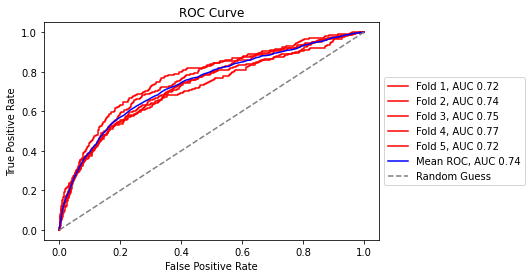

Accuracy for train set: 0.690092936802974
Accuracy for validation set: 0.6893680297397768
No significant overfitting detected.
--------------------------------------------------


Model: SVC


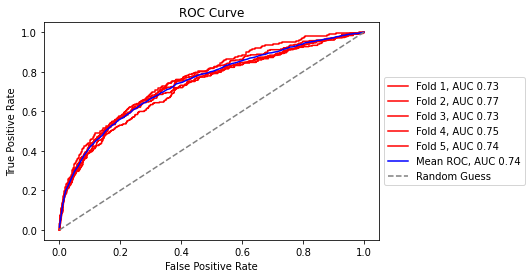

Accuracy for train set: 0.820371747211896
Accuracy for validation set: 0.815092936802974
No significant overfitting detected.
--------------------------------------------------


Model: DecisionTreeClassifier


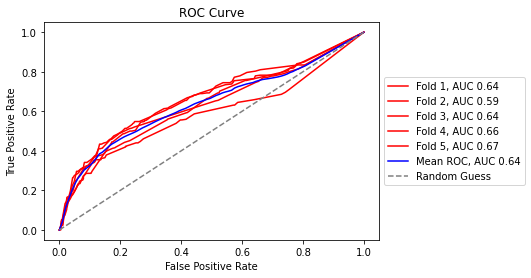

Accuracy for train set: 0.788903345724907
Accuracy for validation set: 0.7222304832713755
No significant overfitting detected.
--------------------------------------------------


Model: RandomForestClassifier


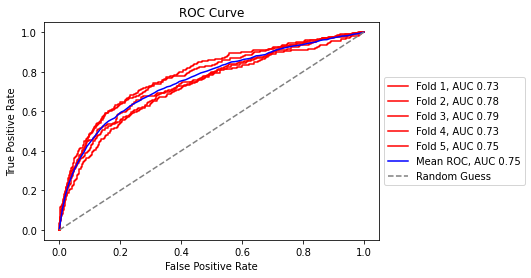

Accuracy for train set: 0.919275092936803
Accuracy for validation set: 0.8381412639405204
No significant overfitting detected.
--------------------------------------------------




In [101]:
# Create an array of classifiers with their best parameters obtained from GridSearchCV
clf_arr = [
    LogisticRegression(**GS1.best_params_, solver='liblinear', max_iter=1000, class_weight='balanced'),  # Logistic Regression
    SVC(**GS2.best_params_,class_weight='balanced'),  # Support Vector Classifier
    DecisionTreeClassifier(**GS3.best_params_,class_weight='balanced'),  # Decision Tree Classifier
    RandomForestClassifier(**GS4.best_params_,class_weight='balanced')  # Random Forest Classifier
]

# Iterate over each classifier in the array
for clf in clf_arr:
    # Run the classifier and plot the ROC curve with the calculated AUC
    KfoldPlot(X_final, y_final, clf, 5)

## Confusion matrix

The provided code evaluates our Random Forest Classifier model on a balanced dataset (Using class_weight='balanced' ensures that the model adjusts weights inversely proportional to class frequencies in the dataset, which helps in dealing with imbalanced classes by giving more importance to the minority class). It splits the data into training and validation sets, trains the model, makes predictions on the validation set, and calculates various performance metrics including accuracy, precision, recall, specificity, and false positive rate. Additionally, it visualizes the model's performance using a confusion matrix to understand how well it classifies different categories.

Train Set:

Train Accuracy: 0.9181
Train Precision: 0.5927
Train Sensitivity (Recall): 0.9141
Train Specificity: 0.9186
Train False Positive Rate (FPR): 0.0814


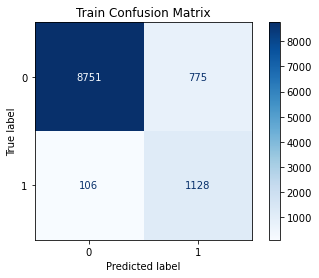

--------------------------------------------------


Validation Set:

Validation Accuracy: 0.8416
Validation Precision: 0.3549
Validation Sensitivity (Recall): 0.4852
Validation Specificity: 0.8872
Validation False Positive Rate (FPR): 0.1128


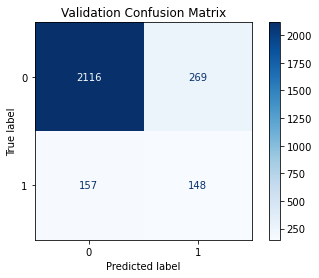

In [110]:
# Split data into training and validation sets (20% validation)
X_train, X_val, y_train, y_val = train_test_split(X_final, y_final, test_size=0.2, random_state=42, shuffle=True)

# Create a Random Forest Classifier with balanced class weights
clf = RandomForestClassifier(**GS4.best_params_, class_weight='balanced')

# Train the classifier on the training data
clf.fit(X_train, y_train)

# Make predictions on the validation and train data
y_val_pred = clf.predict(X_val)
y_train_pred = clf.predict(X_train)
# Evaluate model performance

print("Train Set:"+"\n")

# Calculate accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"Train Accuracy: {train_accuracy:.4f}")  # Format accuracy to 4 decimal places


# Calculate precision
train_precision = precision_score(y_train, y_train_pred)
print(f"Train Precision: {train_precision:.4f}")


# Calculate sensitivity (recall)
train_sensitivity = recall_score(y_train, y_train_pred)
print(f"Train Sensitivity (Recall): {train_sensitivity:.4f}")


# Calculate specificity
tn_train, fp_train, fn_train, tp_train = confusion_matrix(y_train, y_train_pred).ravel()
train_specificity = tn_train / (tn_train + fp_train)
print(f"Train Specificity: {train_specificity:.4f}")


# Calculate False Positive Rate (FPR)
train_fpr = fp_train / (fp_train + tn_train)
print(f"Train False Positive Rate (FPR): {train_fpr:.4f}")


# Create and display the confusion matrix
cm_train = confusion_matrix(y_train, y_train_pred)
display = ConfusionMatrixDisplay(confusion_matrix=cm_train)

display.plot(cmap='Blues')  # Use a colormap for better visualization
plt.title("Train Confusion Matrix")
plt.show()

print('-' * 50)
print("\n")

print("Validation Set:"+"\n")

# Calculate accuracy
val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"Validation Accuracy: {val_accuracy:.4f}")  # Format accuracy to 4 decimal places

# Calculate precision
val_precision = precision_score(y_val, y_val_pred)
print(f"Validation Precision: {val_precision:.4f}")

# Calculate sensitivity (recall)
val_sensitivity = recall_score(y_val, y_val_pred)
print(f"Validation Sensitivity (Recall): {val_sensitivity:.4f}")

# Calculate specificity
tn_val, fp_val, fn_val, tp_val = confusion_matrix(y_val, y_val_pred).ravel()
val_specificity = tn_val / (tn_val + fp_val)
print(f"Validation Specificity: {val_specificity:.4f}")

# Calculate False Positive Rate (FPR)
val_fpr = fp_val / (fp_val + tn_val)
print(f"Validation False Positive Rate (FPR): {val_fpr:.4f}")

# Create and display the confusion matrix
cm_val = confusion_matrix(y_val, y_val_pred)
display = ConfusionMatrixDisplay(confusion_matrix=cm_val)
display.plot(cmap='Blues')  # Use a colormap for better visualization
plt.title("Validation Confusion Matrix")
plt.show()

# Test Set

### Preprocessing
After loading the test set, the following code perform the same preprocessing that was performed on the the train set, on the test set: it applies the Outlier function, drops the 'current_campaign_contacts.1' column, fills the missing values in the same way, maps incorrect values, applies label encoding to categorical variables, performs one-hot encoding for categorical features and finally scales the data.

In [103]:
df_test = pd.read_csv("test_telecom_marketing_data.csv") # Load the test.csv

# Apply the outlier handling function
df_test = Outliers(df_test)

# Drop the 'current_campaign_contacts.1' column
df_test = df_test.drop(columns=['current_campaign_contacts.1'],axis=1)

# Fill missing values in 'previous_campaign_outcome' with 'other'
df_test['previous_campaign_outcome'] = df_test['previous_campaign_outcome'].fillna("other")

# Apply the mapping_wrong_values function
df_test = mapping_wrong_values(df_test)

# Apply KNN imputation for missing values
df_test = Knn_fill(df_test)

# Perform label encoding for categorical features
df_test = label_coding(df_test)

# Perform one-hot encoding for categorical features
df_test = one_hot_encoding(df_test)

# Apply scaling to numerical features
df_test = scaling(df_test)

# Display the preprocessed dataset
df_test

,customer_id,customer_age,day_of_week,current_campaign_contacts,previous_campaign_contacts,B,C,D,job_type_blue-collar,job_type_entrepreneur,...,Month_Number_2.0,Month_Number_3.0,Month_Number_4.0,Month_Number_5.0,Month_Number_6.0,Month_Number_7.0,Month_Number_8.0,Month_Number_9.0,education_level_Number_2.0,education_level_Number_3.0
0,127569.0,0.349515,0.633333,0.2,0.000000,0.378248,0.721572,0.737918,0,0,...,0,0,0,0,1,0,0,0,1,0
1,120141.0,0.330097,0.600000,0.6,0.000000,0.474174,0.130498,0.169617,0,0,...,0,0,0,1,0,0,0,0,1,0
2,127061.0,0.349515,0.566667,0.0,0.000000,0.155496,0.550521,0.843268,1,0,...,0,0,0,0,1,0,0,0,1,0
3,122873.0,0.213592,0.900000,0.0,0.000000,0.222214,0.657960,0.488831,0,0,...,0,0,0,1,0,0,0,0,1,0
4,157685.0,0.252427,0.433333,0.0,0.142857,0.415065,0.373325,0.354804,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2369,133305.0,0.310680,0.900000,0.6,0.000000,0.315834,0.911056,0.498997,1,0,...,0,0,0,0,0,1,0,0,1,0
2370,134528.0,0.504854,1.000000,0.4,0.000000,0.758340,0.599317,0.442344,0,0,...,0,0,0,0,0,1,0,0,0,1
2371,144583.0,0.524272,0.966667,0.0,0.000000,0.366180,0.375994,0.611831,0,0,...,0,0,0,0,0,0,0,0,1,0
2372,160981.0,0.737864,0.700000,0.0,0.571429,0.230131,0.312549,0.708464,0,0,...,0,0,0,0,0,0,0,0,0,0


### PCA
This code applies PCA transformation to the test dataset df_test by first removing the 'customer_id' column. It then transforms the data using an existing PCA model, resulting in X_test_pca. Column names for the principal components are generated as 'PC1', 'PC2', etc., and a new DataFrame, X_pca_df, is created with these columns for further analysis.

In [104]:
#### PCA Transformation for Test Data
# Drop the 'customer_id' column from the test data as it is not needed for PCA
X_test = df_test.drop(columns=['customer_id'])

# Apply the previously fitted PCA model to the test data to transform it into principal component space
X_test_pca = pca.transform(X_test)

# Generate column names for the principal components, e.g., 'PC1', 'PC2', etc.
pca_columns = [f'PC{i+1}' for i in range(X_test_pca.shape[1])]

# Create a DataFrame from the transformed test data, using the generated column names
X_pca_df = pd.DataFrame(X_test_pca, columns=pca_columns)

# Display the DataFrame containing the principal components of the test data
X_pca_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC20,PC21,PC22,PC23,PC24,PC25,PC26,PC27,PC28,PC29
0,0.780489,-0.180659,-0.314204,1.418545,0.499784,-0.093288,-0.611741,0.039889,0.360453,0.510971,...,0.003039,-0.057254,0.130694,-0.040975,-0.068062,0.168282,0.115700,0.197991,0.207350,0.012188
1,0.885102,0.381667,0.977507,0.644403,-0.092957,0.163497,-0.131823,-0.236790,-0.378837,-0.586808,...,-0.177900,0.047209,-0.032475,0.283540,0.404838,-0.192589,-0.183774,-0.356449,-0.317603,-0.065685
2,0.923347,0.022015,0.199688,1.293511,0.504677,-0.102047,0.741883,-0.275178,0.248048,0.205631,...,0.292539,0.437203,0.039248,-0.160684,-0.062662,0.216473,0.154346,0.031544,0.274189,0.008003
3,1.380835,0.081188,-0.190645,0.003706,0.786853,-0.274925,-0.505596,0.078492,0.119746,-0.589461,...,0.180573,0.068322,0.281982,-0.095585,-0.021876,-0.013801,-0.047854,0.160297,0.027814,0.024669
4,-0.974457,0.005317,-0.463478,-0.141122,-0.097312,0.797922,-0.529809,-0.457331,0.311880,0.647698,...,0.072589,0.133553,0.015044,-0.122763,-0.049462,0.031194,-0.109052,-0.094393,-0.145360,0.028044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2369,-0.130044,-1.022846,-0.420081,0.093655,-0.180328,0.739918,0.803987,0.355636,-0.527620,-0.163405,...,-0.016446,0.157682,0.075280,-0.172669,0.011375,-0.081137,-0.070561,0.400259,0.121798,0.051879
2370,-0.905805,0.507798,-0.700362,-0.340662,0.850728,-0.390769,0.089237,0.876637,0.031266,-0.132383,...,-0.072124,-0.020910,0.224108,-0.127010,-0.026471,0.042312,-0.060597,0.116773,-0.028766,0.017558
2371,-0.377842,-0.474411,1.047441,0.367877,-0.703019,-0.430152,0.141950,-0.156920,-0.012441,-0.326234,...,-0.321328,0.090268,0.352145,0.103197,-0.174368,0.273804,-0.080334,-0.263740,0.110932,0.721162
2372,-0.625865,-0.155050,0.161170,0.284082,-0.037994,0.047008,0.253815,-0.309321,0.062761,-0.068954,...,0.237093,0.160464,0.318053,0.643675,0.207923,0.374699,0.046007,-0.342476,0.113405,0.689714


### Predcition using Random Forest
This code prepares data for classification by separating features (X_final) from the target variable (y_final) in the final_df DataFrame. A RandomForestClassifier is initialized with the best parameters from a grid search (GS4.best_params_) and is trained on the entire training dataset. It then creates a pred_df DataFrame with customer IDs and predicted probabilities of the positive class for each customer from the PCA-transformed test data (X_pca_df). Finally, the DataFrame is saved to a CSV file named 'Submission_group_18.csv'.

In [105]:
### prediction
# Prepare the feature matrix (X) and target vector (y)
X_final = final_df.drop(columns=['subscribed_to_new_plan'])
y_final = final_df['subscribed_to_new_plan']
# Initialize and train the Random Forest Classifier using the best parameters that we got from the grid search
best_clf = RandomForestClassifier(**GS4.best_params_)
best_clf.fit(X_final, y_final)  # Fit on the entire training set
# Create a DataFrame to store predictions
pred_df = pd.DataFrame()
# Assign customer IDs from the test dataset to the prediction DataFrame
pred_df["id"] = df_test["customer_id"]
pred_df["id"] = pred_df["id"].astype(int)  # Ensure customer IDs are integers
# Predict the probabilities of the positive class and add to the DataFrame
pred_df["predict_prob"] = best_clf.predict_proba(X_pca_df)[:, 1]
# Save the predictions to a CSV file
pred_df.to_csv('Submission_group_18.csv', index=False)

In [106]:
#The time it took to run the entire code
toc = time.perf_counter()
print(f"The time it took to run the entire code is: {(toc - tic)/60} minutes")

The time it took to run the entire code is: 39.71676651 minuts
